### Baseline Model on Main Application Table

In [12]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import ID_COL, TARGET_COL, FIG_DIR, REPORT_DIR, SUBMISSION_DIR, RANDOM_STATE
from src.data_loader import load_application_data
from src.preprocessing import prepare_main_table_baseline
from src.train import train_catboost_cv
from src.inference import build_submission, build_baseline_report

In [13]:
train, test, sample_sub, data_dir = load_application_data()

print("DATA_DIR:", data_dir)
print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head())
display(test.head())
display(sample_sub.head())

DATA_DIR: C:\Coding\Home-Credit-Default-Risk\data\raw
Train shape: (307511, 122)
Test shape : (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.0000","406,597.5000","24,700.5000","351,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,"-3,648.0000",-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,"-1,134.0000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,"270,000.0000","1,293,502.5000","35,698.5000","1,129,500.0000",Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,"-1,186.0000",-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.0000","135,000.0000","6,750.0000","135,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,"-4,260.0000",-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,"135,000.0000","568,800.0000","20,560.5000","450,000.0000",Unaccompanied,Working,Higher education,Married,House / apartment,0.0188,-19241,-2329,"-5,170.0000",-812,NaN,1,1,0,1,0,1,NaN,2.0000,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.7526,0.7897,0.1595,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0000,0.0000,0.0000,0.0000,"-1,740.0000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,100005,Cash loans,M,N,Y,0,"99,000.0000","222,768.0000","17,370.0000","180,000.0000",Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.0358,-18064,-4469,"-9,118.0000",-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0000,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.5650,0.2917,0.4330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000
2,100013,Cash loans,M,Y,Y,0,"202,500.0000","663,264.0000","69,777.0000","630,000.0000",NaN,Working,Higher education,Married,House / apartment,0.0191,-20038,-4458,"-2,175.0000",-3503,5.0000,1,1,0,1,0,0,Drivers,2.0000,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.6998,0.6110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-856.0000,0,0,0,0,0,0,1,0,0,0,0

,SK_ID_CURR,TARGET
0,100001,0.5000
1,100005,0.5000
2,100013,0.5000
3,100028,0.5000
4,100038,0.5000


In [14]:
X, y, X_test, test_ids, categorical_cols, numeric_cols = prepare_main_table_baseline(train, test)

print("Number of features:", X.shape[1])
print("Number of categorical columns:", len(categorical_cols))
print("Number of numeric columns:", len(numeric_cols))

print("\nTARGET distribution:")
print(y.value_counts().sort_index())

print("\nTARGET proportion:")
print(y.value_counts(normalize=True).sort_index())

Number of features: 121
Number of categorical columns: 16
Number of numeric columns: 105

TARGET distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET proportion:
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64


In [15]:
results = train_catboost_cv(
    X=X,
    y=y,
    X_test=X_test,
    categorical_cols=categorical_cols,
    random_state=RANDOM_STATE,
)

print("Fold AUC scores:", [round(score, 6) for score in results["fold_scores"]])
print("Mean fold AUC :", round(np.mean(results["fold_scores"]), 6))
print("OOF AUC       :", round(results["overall_auc"], 6))

Fold 1 AUC: 0.755092
Fold 2 AUC: 0.765237
Fold 3 AUC: 0.758302
Fold 4 AUC: 0.765160
Fold 5 AUC: 0.755821
Fold AUC scores: [0.755092, 0.765237, 0.758302, 0.76516, 0.755821]
Mean fold AUC : 0.759922
OOF AUC       : 0.759895


In [16]:
oof_df = train[[ID_COL, TARGET_COL]].copy()
oof_df["OOF_PRED"] = results["oof_preds"]

display(oof_df.head(10))

,SK_ID_CURR,TARGET,OOF_PRED
0,100002,1,0.9006
1,100003,0,0.3144
2,100004,0,0.3212
3,100006,0,0.4427
4,100007,0,0.5662
5,100008,0,0.4550
6,100009,0,0.1043
7,100010,0,0.2273
8,100011,0,0.3742
9,100012,0,0.2461


In [17]:
submission = build_submission(
    test_ids=test_ids,
    test_preds=results["test_preds"],
    id_col=ID_COL,
)

submission_path = SUBMISSION_DIR / "baseline_main_table_catboost.csv"
submission.to_csv(submission_path, index=False)

print("Submission saved to:", submission_path)
display(submission.head())

Submission saved to: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\baseline_main_table_catboost.csv


,SK_ID_CURR,TARGET
0,100001,0.2811
1,100005,0.6266
2,100013,0.1738
3,100028,0.2887
4,100038,0.6586


,feature,importance
39,EXT_SOURCE_3,16.5932
38,EXT_SOURCE_2,11.2240
37,EXT_SOURCE_1,7.1000
1,AMT_CREDIT,5.6048
22,DAYS_BIRTH,4.9031
2,AMT_GOODS_PRICE,4.6450
0,AMT_ANNUITY,4.5031
23,DAYS_EMPLOYED,3.4117
25,DAYS_ID_PUBLISH,2.1415
89,NAME_EDUCATION_TYPE,2.0908


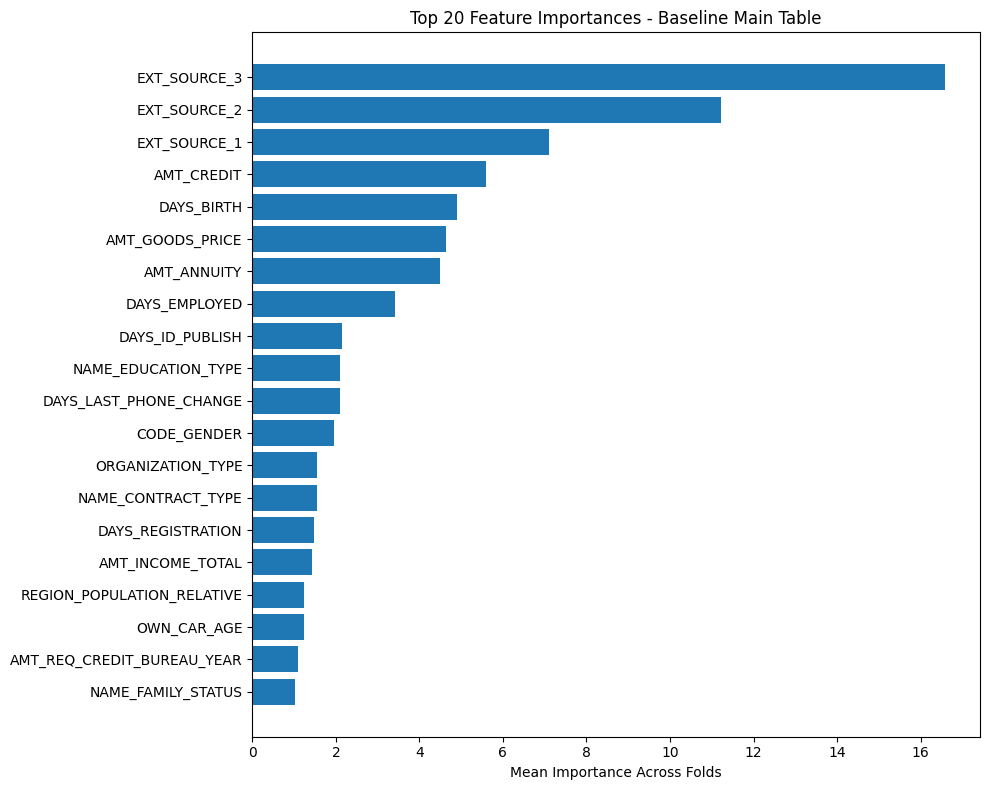

Figure saved to: C:\Coding\Home-Credit-Default-Risk\outputs\figures\baseline_main_table_feature_importance.png


In [18]:
feature_importance = results["feature_importance"]
display(feature_importance.head(20))

plot_df = feature_importance.head(20).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 20 Feature Importances - Baseline Main Table")
plt.xlabel("Mean Importance Across Folds")
plt.tight_layout()

fig_path = FIG_DIR / "baseline_main_table_feature_importance.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", fig_path)

In [19]:
report_text = build_baseline_report(
    train_shape=train.shape,
    test_shape=test.shape,
    positive_rate=y.mean(),
    n_categorical=len(categorical_cols),
    n_numeric=len(numeric_cols),
    n_splits=results["n_splits"],
    fold_scores=results["fold_scores"],
    overall_auc=results["overall_auc"],
    submission_path=submission_path,
    fig_path=fig_path,
)

report_path = REPORT_DIR / "baseline_results.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Report saved to:", report_path)

Report saved to: C:\Coding\Home-Credit-Default-Risk\outputs\reports\baseline_results.md


In [3]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, ID_COL

In [4]:
train = pd.read_csv(RAW_DATA_DIR / "application_train.csv", usecols=["SK_ID_CURR"])
test = pd.read_csv(RAW_DATA_DIR / "application_test.csv", usecols=["SK_ID_CURR"])

bureau = pd.read_csv(RAW_DATA_DIR / "bureau.csv")
bureau_balance = pd.read_csv(RAW_DATA_DIR / "bureau_balance.csv")

base = pd.concat([train, test], axis=0, ignore_index=True)
base = base.drop_duplicates(subset=["SK_ID_CURR"]).reset_index(drop=True)

print(train.shape, test.shape, base.shape)
print(bureau.shape, bureau_balance.shape)

(307511, 1) (48744, 1) (356255, 1)
(1716428, 17) (27299925, 3)


In [5]:
display(bureau.head())
display(bureau_balance.head())

print("bureau unique SK_ID_CURR:", bureau["SK_ID_CURR"].nunique())
print("bureau unique SK_ID_BUREAU:", bureau["SK_ID_BUREAU"].nunique())
print("bureau_balance unique SK_ID_BUREAU:", bureau_balance["SK_ID_BUREAU"].nunique())

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


bureau unique SK_ID_CURR: 305811
bureau unique SK_ID_BUREAU: 1716428
bureau_balance unique SK_ID_BUREAU: 817395


In [7]:
bb = bureau_balance.copy()
status_dummies = pd.get_dummies(bb["STATUS"], prefix="BB_STATUS")
bb = pd.concat([bb, status_dummies], axis=1)

In [9]:
bb_agg = bb.groupby("SK_ID_BUREAU").agg(
    BB_MONTHS_MIN=("MONTHS_BALANCE", "min"),
    BB_MONTHS_MAX=("MONTHS_BALANCE", "max"),
    BB_MONTHS_COUNT=("MONTHS_BALANCE", "count"),
)

status_cols = [c for c in bb.columns if c.startswith("BB_STATUS_")]

bb_status_agg = bb.groupby("SK_ID_BUREAU")[status_cols].agg(["mean", "sum"])
bb_status_agg.columns = [
    f"{col}_{stat}".upper() for col, stat in bb_status_agg.columns
]
bb_status_agg = bb_status_agg.reset_index()

bb_agg = bb_agg.reset_index().merge(bb_status_agg, on="SK_ID_BUREAU", how="left")
bb_agg.head()

,SK_ID_BUREAU,BB_MONTHS_MIN,BB_MONTHS_MAX,BB_MONTHS_COUNT,BB_STATUS_0_MEAN,BB_STATUS_0_SUM,BB_STATUS_1_MEAN,BB_STATUS_1_SUM,BB_STATUS_2_MEAN,BB_STATUS_2_SUM,BB_STATUS_3_MEAN,BB_STATUS_3_SUM,BB_STATUS_4_MEAN,BB_STATUS_4_SUM,BB_STATUS_5_MEAN,BB_STATUS_5_SUM,BB_STATUS_C_MEAN,BB_STATUS_C_SUM,BB_STATUS_X_MEAN,BB_STATUS_X_SUM
0,5001709,-96,0,97,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.886598,86,0.113402,11
1,5001710,-82,0,83,0.060241,5,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.578313,48,0.361446,30
2,5001711,-3,0,4,0.750000,3,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.000000,0,0.250000,1
3,5001712,-18,0,19,0.526316,10,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.473684,9,0.000000,0
4,5001713,-21,0,22,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.000000,0,1.000000,22


In [10]:
bureau_full = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")
print(bureau_full.shape)

(1716428, 36)


In [11]:
bureau_full["CREDIT_ACTIVE_IS_ACTIVE"] = (bureau_full["CREDIT_ACTIVE"] == "Active").astype(int)
bureau_full["CREDIT_ACTIVE_IS_CLOSED"] = (bureau_full["CREDIT_ACTIVE"] == "Closed").astype(int)

bureau_full["HAS_DEBT"] = (bureau_full["AMT_CREDIT_SUM_DEBT"].fillna(0) > 0).astype(int)
bureau_full["HAS_OVERDUE"] = (bureau_full["AMT_CREDIT_SUM_OVERDUE"].fillna(0) > 0).astype(int)

bureau_full["DEBT_CREDIT_RATIO"] = (
    bureau_full["AMT_CREDIT_SUM_DEBT"] / bureau_full["AMT_CREDIT_SUM"]
).replace([np.inf, -np.inf], np.nan)

bureau_full["OVERDUE_DEBT_RATIO"] = (
    bureau_full["AMT_CREDIT_SUM_OVERDUE"] / bureau_full["AMT_CREDIT_SUM_DEBT"]
).replace([np.inf, -np.inf], np.nan)

In [15]:
agg_dict = {
    "SK_ID_BUREAU": "count",
    "CREDIT_ACTIVE_IS_ACTIVE": "sum",
    "CREDIT_ACTIVE_IS_CLOSED": "sum",
    "HAS_DEBT": "sum",
    "HAS_OVERDUE": "sum",
    "DAYS_CREDIT": ["mean", "max"],
    "DAYS_CREDIT_UPDATE": "mean",
    "AMT_CREDIT_SUM": ["mean", "sum"],
    "AMT_CREDIT_SUM_DEBT": ["mean", "sum"],
    "AMT_CREDIT_SUM_OVERDUE": "max",
    "DEBT_CREDIT_RATIO": "mean",
    "OVERDUE_DEBT_RATIO": "mean",
    "BB_MONTHS_COUNT": ["mean", "max"],
}

bb_status_mean_cols = [
    c for c in bureau_full.columns
    if c.startswith("BB_STATUS_") and c.endswith("_MEAN")
]

bb_status_sum_cols = [
    c for c in bureau_full.columns
    if c.startswith("BB_STATUS_") and c.endswith("_SUM")
]

for col in bb_status_mean_cols:
    agg_dict[col] = "mean"

for col in bb_status_sum_cols:
    agg_dict[col] = "sum"

bureau_curr_agg = bureau_full.groupby("SK_ID_CURR").agg(agg_dict)

bureau_curr_agg.columns = [
    "BUREAU_" + "_".join(col).upper() if isinstance(col, tuple) else "BUREAU_" + col.upper()
    for col in bureau_curr_agg.columns
]

bureau_curr_agg = bureau_curr_agg.reset_index()

bureau_curr_agg["BUREAU_ACTIVE_RATIO"] = (
    bureau_curr_agg["BUREAU_CREDIT_ACTIVE_IS_ACTIVE_SUM"] /
    bureau_curr_agg["BUREAU_SK_ID_BUREAU_COUNT"]
)

bureau_curr_agg["BUREAU_CLOSED_RATIO"] = (
    bureau_curr_agg["BUREAU_CREDIT_ACTIVE_IS_CLOSED_SUM"] /
    bureau_curr_agg["BUREAU_SK_ID_BUREAU_COUNT"]
)

bureau_curr_agg["BUREAU_OVERDUE_RATIO"] = (
    bureau_curr_agg["BUREAU_HAS_OVERDUE_SUM"] /
    bureau_curr_agg["BUREAU_SK_ID_BUREAU_COUNT"]
)

In [16]:
bureau_features = base.merge(bureau_curr_agg, on="SK_ID_CURR", how="left")

print(bureau_features.shape)
print(bureau_features["SK_ID_CURR"].nunique())
display(bureau_features.head())
display(bureau_features.isnull().mean().sort_values(ascending=False).head(20))

(356255, 37)
356255


,SK_ID_CURR,BUREAU_SK_ID_BUREAU_COUNT,BUREAU_CREDIT_ACTIVE_IS_ACTIVE_SUM,BUREAU_CREDIT_ACTIVE_IS_CLOSED_SUM,BUREAU_HAS_DEBT_SUM,BUREAU_HAS_OVERDUE_SUM,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_AMT_CREDIT_SUM_MEAN,...,BUREAU_BB_STATUS_1_SUM_SUM,BUREAU_BB_STATUS_2_SUM_SUM,BUREAU_BB_STATUS_3_SUM_SUM,BUREAU_BB_STATUS_4_SUM_SUM,BUREAU_BB_STATUS_5_SUM_SUM,BUREAU_BB_STATUS_C_SUM_SUM,BUREAU_BB_STATUS_X_SUM_SUM,BUREAU_ACTIVE_RATIO,BUREAU_CLOSED_RATIO,BUREAU_OVERDUE_RATIO
0,100002,8.0,2.0,6.0,1.0,0.0,-874.00,-103.0,-499.875,108131.945625,...,27.0,0.0,0.0,0.0,0.0,23.0,15.0,0.25,0.75,0.0
1,100003,4.0,1.0,3.0,0.0,0.0,-1400.75,-606.0,-816.000,254350.125000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.75,0.0
2,100004,2.0,0.0,2.0,0.0,0.0,-867.00,-408.0,-532.000,94518.900000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.00,0.0
3,100006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,1.0,0.0,1.0,0.0,0.0,-1149.00,-1149.0,-783.000,146250.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.00,0.0


BUREAU_BB_STATUS_0_MEAN_MEAN       0.622344
BUREAU_BB_STATUS_C_MEAN_MEAN       0.622344
BUREAU_BB_STATUS_4_MEAN_MEAN       0.622344
BUREAU_BB_STATUS_3_MEAN_MEAN       0.622344
BUREAU_BB_STATUS_2_MEAN_MEAN       0.622344
BUREAU_BB_STATUS_1_MEAN_MEAN       0.622344
BUREAU_BB_STATUS_X_MEAN_MEAN       0.622344
BUREAU_BB_MONTHS_COUNT_MAX         0.622344
BUREAU_BB_MONTHS_COUNT_MEAN        0.622344
BUREAU_BB_STATUS_5_MEAN_MEAN       0.622344
BUREAU_OVERDUE_DEBT_RATIO_MEAN     0.391489
BUREAU_DEBT_CREDIT_RATIO_MEAN      0.169210
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN    0.165095
BUREAU_AMT_CREDIT_SUM_MEAN         0.141601
BUREAU_BB_STATUS_2_SUM_SUM         0.141595
BUREAU_BB_STATUS_0_SUM_SUM         0.141595
BUREAU_BB_STATUS_3_SUM_SUM         0.141595
BUREAU_BB_STATUS_4_SUM_SUM         0.141595
BUREAU_BB_STATUS_5_SUM_SUM         0.141595
BUREAU_BB_STATUS_C_SUM_SUM         0.141595
dtype: float64

In [17]:
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
bureau_features.to_parquet(PROCESSED_DATA_DIR / "bureau_features.parquet", index=False)

In [18]:
from src.features_bureau import build_bureau_features

bureau_features = build_bureau_features(save=True)
print(bureau_features.shape)
display(bureau_features.head())

(356255, 37)


,SK_ID_CURR,BUREAU_SK_ID_BUREAU_COUNT,BUREAU_CREDIT_ACTIVE_IS_ACTIVE_SUM,BUREAU_CREDIT_ACTIVE_IS_CLOSED_SUM,BUREAU_HAS_DEBT_SUM,BUREAU_HAS_OVERDUE_SUM,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_AMT_CREDIT_SUM_MEAN,...,BUREAU_BB_STATUS_1_SUM_SUM,BUREAU_BB_STATUS_2_SUM_SUM,BUREAU_BB_STATUS_3_SUM_SUM,BUREAU_BB_STATUS_4_SUM_SUM,BUREAU_BB_STATUS_5_SUM_SUM,BUREAU_BB_STATUS_C_SUM_SUM,BUREAU_BB_STATUS_X_SUM_SUM,BUREAU_ACTIVE_RATIO,BUREAU_CLOSED_RATIO,BUREAU_OVERDUE_RATIO
0,100002,8.0,2.0,6.0,1.0,0.0,-874.00,-103.0,-499.875,108131.945625,...,27.0,0.0,0.0,0.0,0.0,23.0,15.0,0.25,0.75,0.0
1,100003,4.0,1.0,3.0,0.0,0.0,-1400.75,-606.0,-816.000,254350.125000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.75,0.0
2,100004,2.0,0.0,2.0,0.0,0.0,-867.00,-408.0,-532.000,94518.900000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.00,0.0
3,100006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,1.0,0.0,1.0,0.0,0.0,-1149.00,-1149.0,-783.000,146250.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.00,0.0


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.6f}".format)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import (
    ID_COL,
    TARGET_COL,
    RANDOM_STATE,
    PROCESSED_DATA_DIR,
    SUBMISSION_DIR,
    REPORT_DIR,
    FIG_DIR,
)
from src.data_loader import load_application_data
from src.preprocessing import prepare_main_table_with_bureau
from src.train import train_catboost_cv
from src.features_bureau import build_bureau_features

In [2]:
train, test, sample_sub, data_dir = load_application_data()

bureau_path = PROCESSED_DATA_DIR / "bureau_features.parquet"

if bureau_path.exists():
    bureau_features = pd.read_parquet(bureau_path)
else:
    bureau_features = build_bureau_features(save=True)

print("DATA_DIR:", data_dir)
print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Bureau features shape:", bureau_features.shape)

display(bureau_features.head())

DATA_DIR: C:\Coding\Home-Credit-Default-Risk\data\raw
Train shape: (307511, 122)
Test shape : (48744, 121)
Bureau features shape: (356255, 37)


,SK_ID_CURR,BUREAU_SK_ID_BUREAU_COUNT,BUREAU_CREDIT_ACTIVE_IS_ACTIVE_SUM,BUREAU_CREDIT_ACTIVE_IS_CLOSED_SUM,BUREAU_HAS_DEBT_SUM,BUREAU_HAS_OVERDUE_SUM,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX,BUREAU_DEBT_CREDIT_RATIO_MEAN,BUREAU_OVERDUE_DEBT_RATIO_MEAN,BUREAU_BB_MONTHS_COUNT_MEAN,BUREAU_BB_MONTHS_COUNT_MAX,BUREAU_BB_STATUS_0_MEAN_MEAN,BUREAU_BB_STATUS_1_MEAN_MEAN,BUREAU_BB_STATUS_2_MEAN_MEAN,BUREAU_BB_STATUS_3_MEAN_MEAN,BUREAU_BB_STATUS_4_MEAN_MEAN,BUREAU_BB_STATUS_5_MEAN_MEAN,BUREAU_BB_STATUS_C_MEAN_MEAN,BUREAU_BB_STATUS_X_MEAN_MEAN,BUREAU_BB_STATUS_0_SUM_SUM,BUREAU_BB_STATUS_1_SUM_SUM,BUREAU_BB_STATUS_2_SUM_SUM,BUREAU_BB_STATUS_3_SUM_SUM,BUREAU_BB_STATUS_4_SUM_SUM,BUREAU_BB_STATUS_5_SUM_SUM,BUREAU_BB_STATUS_C_SUM_SUM,BUREAU_BB_STATUS_X_SUM_SUM,BUREAU_ACTIVE_RATIO,BUREAU_CLOSED_RATIO,BUREAU_OVERDUE_RATIO
0,100002,8.000000,2.000000,6.000000,1.000000,0.000000,-874.000000,-103.000000,-499.875000,"108,131.945625","865,055.565000","49,156.200000","245,781.000000",0.000000,0.136545,0.000000,13.750000,22.000000,0.406960,0.255682,0.000000,0.000000,0.000000,0.000000,0.175426,0.161932,45.000000,27.000000,0.000000,0.000000,0.000000,0.000000,23.000000,15.000000,0.250000,0.750000,0.000000
1,100003,4.000000,1.000000,3.000000,0.000000,0.000000,"-1,400.750000",-606.000000,-816.000000,"254,350.125000","1,017,400.500000",0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.750000,0.000000
2,100004,2.000000,0.000000,2.000000,0.000000,0.000000,-867.000000,-408.000000,-532.000000,"94,518.900000","189,037.800000",0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
3,100006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,1.000000,0.000000,1.000000,0.000000,0.000000,"-1,149.000000","-1,149.000000",-783.000000,"146,250.000000","146,250.000000",0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


In [3]:
print("Rows in bureau_features:", len(bureau_features))
print("Unique SK_ID_CURR:", bureau_features[ID_COL].nunique())
print("Is unique key:", bureau_features[ID_COL].is_unique)

bureau_cols = [c for c in bureau_features.columns if c != ID_COL]
print("Number of bureau-derived columns:", len(bureau_cols))

display(
    bureau_features[bureau_cols]
    .isnull()
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

Rows in bureau_features: 356255
Unique SK_ID_CURR: 356255
Is unique key: True
Number of bureau-derived columns: 36


BUREAU_BB_STATUS_1_MEAN_MEAN      0.622344
BUREAU_BB_STATUS_X_MEAN_MEAN      0.622344
BUREAU_BB_STATUS_5_MEAN_MEAN      0.622344
BUREAU_BB_STATUS_4_MEAN_MEAN      0.622344
BUREAU_BB_STATUS_3_MEAN_MEAN      0.622344
BUREAU_BB_STATUS_2_MEAN_MEAN      0.622344
BUREAU_BB_STATUS_0_MEAN_MEAN      0.622344
BUREAU_BB_MONTHS_COUNT_MAX        0.622344
BUREAU_BB_MONTHS_COUNT_MEAN       0.622344
BUREAU_BB_STATUS_C_MEAN_MEAN      0.622344
BUREAU_OVERDUE_DEBT_RATIO_MEAN    0.391489
BUREAU_DEBT_CREDIT_RATIO_MEAN     0.169210
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN   0.165095
BUREAU_AMT_CREDIT_SUM_MEAN        0.141601
BUREAU_BB_STATUS_2_SUM_SUM        0.141595
BUREAU_BB_STATUS_3_SUM_SUM        0.141595
BUREAU_BB_STATUS_4_SUM_SUM        0.141595
BUREAU_BB_STATUS_5_SUM_SUM        0.141595
BUREAU_BB_STATUS_0_SUM_SUM        0.141595
BUREAU_BB_STATUS_C_SUM_SUM        0.141595
dtype: float64

In [4]:
X, y, X_test, test_ids, categorical_cols, numeric_cols = prepare_main_table_with_bureau(
    train=train,
    test=test,
    bureau_features=bureau_features,
)

print("Merged train features:", X.shape)
print("Merged test features :", X_test.shape)
print("Categorical columns  :", len(categorical_cols))
print("Numeric columns      :", len(numeric_cols))

bureau_feature_names = [c for c in X.columns if c.startswith("BUREAU_")]
print("Merged bureau feature count:", len(bureau_feature_names))

display(pd.Series(bureau_feature_names[:30], name="bureau_features_preview"))

Merged train features: (307511, 157)
Merged test features : (48744, 157)
Categorical columns  : 16
Numeric columns      : 141
Merged bureau feature count: 36


0              BUREAU_SK_ID_BUREAU_COUNT
1     BUREAU_CREDIT_ACTIVE_IS_ACTIVE_SUM
2     BUREAU_CREDIT_ACTIVE_IS_CLOSED_SUM
3                    BUREAU_HAS_DEBT_SUM
4                 BUREAU_HAS_OVERDUE_SUM
5                BUREAU_DAYS_CREDIT_MEAN
6                 BUREAU_DAYS_CREDIT_MAX
7         BUREAU_DAYS_CREDIT_UPDATE_MEAN
8             BUREAU_AMT_CREDIT_SUM_MEAN
9              BUREAU_AMT_CREDIT_SUM_SUM
10       BUREAU_AMT_CREDIT_SUM_DEBT_MEAN
11        BUREAU_AMT_CREDIT_SUM_DEBT_SUM
12     BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX
13         BUREAU_DEBT_CREDIT_RATIO_MEAN
14        BUREAU_OVERDUE_DEBT_RATIO_MEAN
15           BUREAU_BB_MONTHS_COUNT_MEAN
16            BUREAU_BB_MONTHS_COUNT_MAX
17          BUREAU_BB_STATUS_0_MEAN_MEAN
18          BUREAU_BB_STATUS_1_MEAN_MEAN
19          BUREAU_BB_STATUS_2_MEAN_MEAN
20          BUREAU_BB_STATUS_3_MEAN_MEAN
21          BUREAU_BB_STATUS_4_MEAN_MEAN
22          BUREAU_BB_STATUS_5_MEAN_MEAN
23          BUREAU_BB_STATUS_C_MEAN_MEAN
24          BURE

In [5]:
results = train_catboost_cv(
    X=X,
    y=y,
    X_test=X_test,
    categorical_cols=categorical_cols,
    random_state=RANDOM_STATE,
)

baseline_mean_auc = 0.759922
baseline_oof_auc = 0.759895

print("Fold AUC scores:", [round(score, 6) for score in results["fold_scores"]])
print("Mean fold AUC :", round(np.mean(results["fold_scores"]), 6))
print("OOF AUC       :", round(results["overall_auc"], 6))
print("Lift vs baseline OOF:", round(results["overall_auc"] - baseline_oof_auc, 6))

Fold 1 AUC: 0.760744
Fold 2 AUC: 0.770255
Fold 3 AUC: 0.764195
Fold 4 AUC: 0.770144
Fold 5 AUC: 0.761541
Fold AUC scores: [0.760744, 0.770255, 0.764195, 0.770144, 0.761541]
Mean fold AUC : 0.765376
OOF AUC       : 0.765354
Lift vs baseline OOF: 0.005459


In [6]:
submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET_COL: results["test_preds"],
})

submission_path = SUBMISSION_DIR / "model_v2_bureau.csv"
submission.to_csv(submission_path, index=False)

comparison_df = pd.DataFrame({
    "model": ["baseline_main_table", "main_table_plus_bureau"],
    "mean_fold_auc": [baseline_mean_auc, np.mean(results["fold_scores"])],
    "oof_auc": [baseline_oof_auc, results["overall_auc"]],
})

comparison_df["oof_lift_vs_baseline"] = comparison_df["oof_auc"] - baseline_oof_auc

print("Submission saved to:", submission_path)
display(submission.head())
display(comparison_df)

Submission saved to: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\model_v2_bureau.csv


,SK_ID_CURR,TARGET
0,100001,0.292829
1,100005,0.678310
2,100013,0.174254
3,100028,0.257261
4,100038,0.661344


,model,mean_fold_auc,oof_auc,oof_lift_vs_baseline
0,baseline_main_table,0.759922,0.759895,0.000000
1,main_table_plus_bureau,0.765376,0.765354,0.005459


,feature,importance,source
75,EXT_SOURCE_3,13.988113,main_table
74,EXT_SOURCE_2,10.833175,main_table
73,EXT_SOURCE_1,6.364396,main_table
1,AMT_CREDIT,4.610291,main_table
58,DAYS_BIRTH,4.190686,main_table
2,AMT_GOODS_PRICE,3.979123,main_table
0,AMT_ANNUITY,3.630004,main_table
46,BUREAU_DEBT_CREDIT_RATIO_MEAN,3.281401,bureau
59,DAYS_EMPLOYED,3.180165,main_table
125,NAME_EDUCATION_TYPE,1.963163,main_table


Top bureau features:


,feature,importance,source
46,BUREAU_DEBT_CREDIT_RATIO_MEAN,3.281401,bureau
19,BUREAU_AMT_CREDIT_SUM_MEAN,1.653535,bureau
43,BUREAU_DAYS_CREDIT_MAX,1.544793,bureau
21,BUREAU_AMT_CREDIT_SUM_SUM,1.180547,bureau
18,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,1.010969,bureau
41,BUREAU_CREDIT_ACTIVE_IS_ACTIVE_SUM,0.914302,bureau
17,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,0.876273,bureau
44,BUREAU_DAYS_CREDIT_MEAN,0.628434,bureau
24,BUREAU_BB_STATUS_0_MEAN_MEAN,0.589155,bureau
45,BUREAU_DAYS_CREDIT_UPDATE_MEAN,0.555244,bureau


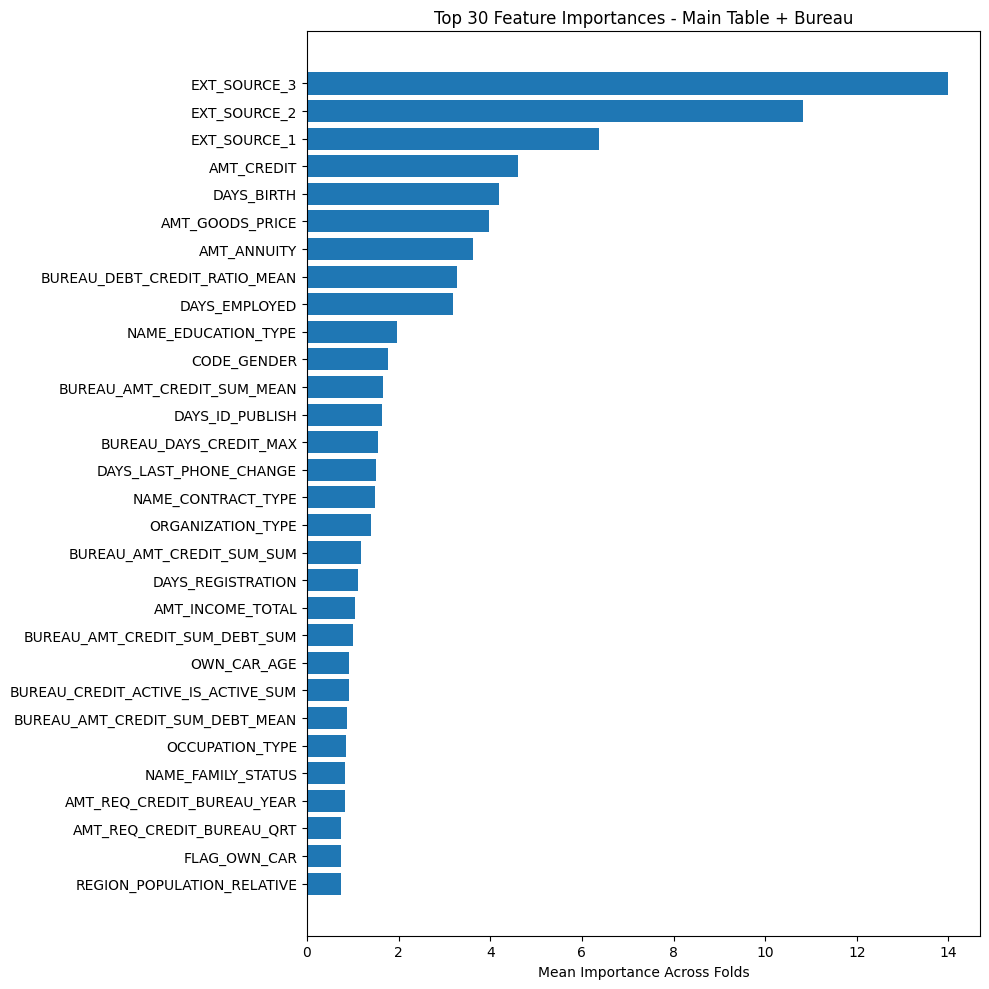

Figure saved to: C:\Coding\Home-Credit-Default-Risk\outputs\figures\model_v2_bureau_feature_importance.png


In [7]:
feature_importance = results["feature_importance"].copy()
feature_importance["source"] = np.where(
    feature_importance["feature"].str.startswith("BUREAU_"),
    "bureau",
    "main_table",
)

display(feature_importance.head(30))

top_bureau_features = feature_importance[
    feature_importance["feature"].str.startswith("BUREAU_")
].head(15)

print("Top bureau features:")
display(top_bureau_features)

plot_df = feature_importance.head(30).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 30 Feature Importances - Main Table + Bureau")
plt.xlabel("Mean Importance Across Folds")
plt.tight_layout()

fig_path = FIG_DIR / "model_v2_bureau_feature_importance.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", fig_path)

In [8]:
report_lines = [
    "# Model V2 Results - Main Table + Bureau",
    "",
    "## Dataset",
    f"- Train shape: {train.shape}",
    f"- Test shape: {test.shape}",
    f"- Bureau feature table shape: {bureau_features.shape}",
    f"- Final merged train feature matrix: {X.shape}",
    f"- Final merged test feature matrix: {X_test.shape}",
    f"- Number of categorical columns: {len(categorical_cols)}",
    f"- Number of numeric columns: {len(numeric_cols)}",
    f"- Number of bureau-derived columns used in model: {len(bureau_feature_names)}",
    "",
    "## Cross-validation",
    f"- Number of folds: {results['n_splits']}",
    f"- Fold AUC scores: {[round(score, 6) for score in results['fold_scores']]}",
    f"- Mean fold AUC: {np.mean(results['fold_scores']):.6f}",
    f"- OOF AUC: {results['overall_auc']:.6f}",
    "",
    "## Baseline Comparison",
    f"- Baseline mean fold AUC: {baseline_mean_auc:.6f}",
    f"- Baseline OOF AUC: {baseline_oof_auc:.6f}",
    f"- OOF lift vs baseline: {results['overall_auc'] - baseline_oof_auc:.6f}",
    "",
    "## Outputs",
    f"- Submission file: {submission_path}",
    f"- Feature importance figure: {fig_path}",
    "",
    "## Notes",
    "- This model adds bureau and bureau_balance aggregated features on top of the main application table.",
    "- Compare whether external credit history improves discrimination over the baseline-only model.",
]

report_text = "\n".join(report_lines)

report_path = REPORT_DIR / "model_v2_with_bureau.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Report saved to:", report_path)

Report saved to: C:\Coding\Home-Credit-Default-Risk\outputs\reports\model_v2_with_bureau.md


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.6f}".format)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import ID_COL, PROCESSED_DATA_DIR
from src.features_previous import (
    load_previous_application_data,
    preprocess_previous_application,
    aggregate_previous_to_curr,
    build_previous_application_features,
)

In [2]:
base, previous = load_previous_application_data()

print("Base shape:", base.shape)
print("Previous application shape:", previous.shape)
print("Unique SK_ID_CURR in previous:", previous["SK_ID_CURR"].nunique())
print("Unique SK_ID_PREV in previous:", previous["SK_ID_PREV"].nunique())

display(previous.head())

Base shape: (356255, 1)
Previous application shape: (1670214, 37)
Unique SK_ID_CURR in previous: 338857
Unique SK_ID_PREV in previous: 1670214


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,"1,730.430000","17,145.000000","17,145.000000",0.000000,"17,145.000000",SATURDAY,15,Y,1,0.000000,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.000000,middle,POS mobile with interest,"365,243.000000",-42.000000,300.000000,-42.000000,-37.000000,0.000000
1,2802425,108129,Cash loans,"25,188.615000","607,500.000000","679,671.000000",NaN,"607,500.000000",THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.000000,low_action,Cash X-Sell: low,"365,243.000000",-134.000000,916.000000,"365,243.000000","365,243.000000",1.000000
2,2523466,122040,Cash loans,"15,060.735000","112,500.000000","136,444.500000",NaN,"112,500.000000",TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.000000,high,Cash X-Sell: high,"365,243.000000",-271.000000,59.000000,"365,243.000000","365,243.000000",1.000000
3,2819243,176158,Cash loans,"47,041.335000","450,000.000000","470,790.000000",NaN,"450,000.000000",MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.000000,middle,Cash X-Sell: middle,"365,243.000000",-482.000000,-152.000000,-182.000000,-177.000000,1.000000
4,1784265,202054,Cash loans,"31,924.395000","337,500.000000","404,055.000000",NaN,"337,500.000000",THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.000000,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print(previous.dtypes.value_counts())
print()
print("Top missing columns:")
display(previous.isnull().mean().sort_values(ascending=False).head(20))

object     16
float64    15
int64       6
Name: count, dtype: int64

Top missing columns:


RATE_INTEREST_PRIVILEGED    0.996437
RATE_INTEREST_PRIMARY       0.996437
AMT_DOWN_PAYMENT            0.536365
RATE_DOWN_PAYMENT           0.536365
NAME_TYPE_SUITE             0.491198
NFLAG_INSURED_ON_APPROVAL   0.402981
DAYS_TERMINATION            0.402981
DAYS_LAST_DUE               0.402981
DAYS_LAST_DUE_1ST_VERSION   0.402981
DAYS_FIRST_DUE              0.402981
DAYS_FIRST_DRAWING          0.402981
AMT_GOODS_PRICE             0.230818
AMT_ANNUITY                 0.222867
CNT_PAYMENT                 0.222864
PRODUCT_COMBINATION         0.000207
AMT_CREDIT                  0.000001
NAME_YIELD_GROUP            0.000000
NAME_PORTFOLIO              0.000000
NAME_SELLER_INDUSTRY        0.000000
SELLERPLACE_AREA            0.000000
dtype: float64

In [4]:
previous_clean = preprocess_previous_application(previous)

engineered_cols = [
    "PREV_IS_APPROVED",
    "PREV_IS_REFUSED",
    "PREV_IS_CANCELED",
    "PREV_IS_UNUSED_OFFER",
    "PREV_APP_CREDIT_DIFF",
    "PREV_APP_CREDIT_RATIO",
    "PREV_CREDIT_GOODS_RATIO",
    "PREV_ANNUITY_CREDIT_RATIO",
    "PREV_DOWNPAYMENT_CREDIT_RATIO",
    "PREV_DAYS_DECISION_ABS",
]

display(previous_clean[["SK_ID_CURR", "SK_ID_PREV"] + engineered_cols].head())

,SK_ID_CURR,SK_ID_PREV,PREV_IS_APPROVED,PREV_IS_REFUSED,PREV_IS_CANCELED,PREV_IS_UNUSED_OFFER,PREV_APP_CREDIT_DIFF,PREV_APP_CREDIT_RATIO,PREV_CREDIT_GOODS_RATIO,PREV_ANNUITY_CREDIT_RATIO,PREV_DOWNPAYMENT_CREDIT_RATIO,PREV_DAYS_DECISION_ABS
0,271877,2030495,1,0,0,0,0.000000,1.000000,1.000000,0.100929,0.000000,73
1,108129,2802425,1,0,0,0,"-72,171.000000",0.893815,1.118800,0.037060,NaN,164
2,122040,2523466,1,0,0,0,"-23,944.500000",0.824511,1.212840,0.110380,NaN,301
3,176158,2819243,1,0,0,0,"-20,790.000000",0.955840,1.046200,0.099920,NaN,512
4,202054,1784265,0,1,0,0,"-66,555.000000",0.835282,1.197200,0.079010,NaN,781


In [5]:
decision_summary = pd.DataFrame({
    "approved_rate": [previous_clean["PREV_IS_APPROVED"].mean()],
    "refused_rate": [previous_clean["PREV_IS_REFUSED"].mean()],
    "canceled_rate": [previous_clean["PREV_IS_CANCELED"].mean()],
    "unused_offer_rate": [previous_clean["PREV_IS_UNUSED_OFFER"].mean()],
})

display(decision_summary)

,approved_rate,refused_rate,canceled_rate,unused_offer_rate
0,0.620747,0.174036,0.189388,0.015828


In [6]:
previous_features_only = aggregate_previous_to_curr(previous_clean)

print("Previous features shape:", previous_features_only.shape)
print("Unique SK_ID_CURR:", previous_features_only[ID_COL].nunique())
print("Is unique key:", previous_features_only[ID_COL].is_unique)

display(previous_features_only.head())

Previous features shape: (338857, 39)
Unique SK_ID_CURR: 338857
Is unique key: True


,SK_ID_CURR,PREV_SK_ID_PREV_COUNT,PREV_PREV_IS_APPROVED_SUM,PREV_PREV_IS_REFUSED_SUM,PREV_PREV_IS_CANCELED_SUM,PREV_PREV_IS_UNUSED_OFFER_SUM,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_CREDIT_MEAN,PREV_AMT_CREDIT_MAX,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_DOWN_PAYMENT_MEAN,PREV_AMT_DOWN_PAYMENT_MAX,PREV_AMT_GOODS_PRICE_MEAN,PREV_AMT_GOODS_PRICE_MAX,PREV_CNT_PAYMENT_MEAN,PREV_CNT_PAYMENT_MAX,PREV_RATE_DOWN_PAYMENT_MEAN,PREV_RATE_DOWN_PAYMENT_MAX,PREV_DAYS_DECISION_MEAN,PREV_DAYS_DECISION_MAX,PREV_PREV_DAYS_DECISION_ABS_MEAN,PREV_PREV_DAYS_DECISION_ABS_MIN,PREV_PREV_APP_CREDIT_DIFF_MEAN,PREV_PREV_APP_CREDIT_DIFF_MAX,PREV_PREV_APP_CREDIT_RATIO_MEAN,PREV_PREV_APP_CREDIT_RATIO_MAX,PREV_PREV_CREDIT_GOODS_RATIO_MEAN,PREV_PREV_ANNUITY_CREDIT_RATIO_MEAN,PREV_PREV_DOWNPAYMENT_CREDIT_RATIO_MEAN,PREV_PREV_APPROVED_AMT_CREDIT_MEAN,PREV_PREV_APPROVED_AMT_CREDIT_MAX,PREV_PREV_APPROVED_AMT_ANNUITY_MEAN,PREV_PREV_APPROVED_AMT_ANNUITY_MAX,PREV_PREV_APPROVED_APP_CREDIT_RATIO_MEAN,PREV_APPROVAL_RATE,PREV_REFUSAL_RATE,PREV_CANCEL_RATE
0,100001,1,1,0,0,0,"24,835.500000","24,835.500000","23,787.000000","23,787.000000","3,951.000000","3,951.000000","2,520.000000","2,520.000000","24,835.500000","24,835.500000",8.000000,8.000000,0.104326,0.104326,"-1,740.000000",-1740,"1,740.000000",1740,"1,048.500000","1,048.500000",1.044079,1.044079,0.957782,0.166099,0.105940,"23,787.000000","23,787.000000","3,951.000000","3,951.000000",1.044079,1.000000,0.000000,0.000000
1,100002,1,1,0,0,0,"179,055.000000","179,055.000000","179,055.000000","179,055.000000","9,251.775000","9,251.775000",0.000000,0.000000,"179,055.000000","179,055.000000",24.000000,24.000000,0.000000,0.000000,-606.000000,-606,606.000000,606,0.000000,0.000000,1.000000,1.000000,1.000000,0.051670,0.000000,"179,055.000000","179,055.000000","9,251.775000","9,251.775000",1.000000,1.000000,0.000000,0.000000
2,100003,3,3,0,0,0,"435,436.500000","900,000.000000","484,191.000000","1,035,882.000000","56,553.990000","98,356.995000","3,442.500000","6,885.000000","435,436.500000","900,000.000000",10.000000,12.000000,0.050030,0.100061,"-1,305.000000",-746,"1,305.000000",746,"-48,754.500000",756.000000,0.949329,1.011109,1.057664,0.126383,0.050585,"484,191.000000","1,035,882.000000","56,553.990000","98,356.995000",0.949329,1.000000,0.000000,0.000000
3,100004,1,1,0,0,0,"24,282.000000","24,282.000000","20,106.000000","20,106.000000","5,357.250000","5,357.250000","4,860.000000","4,860.000000","24,282.000000","24,282.000000",4.000000,4.000000,0.212008,0.212008,-815.000000,-815,815.000000,815,"4,176.000000","4,176.000000",1.207699,1.207699,0.828021,0.266450,0.241719,"20,106.000000","20,106.000000","5,357.250000","5,357.250000",1.207699,1.000000,0.000000,0.000000
4,100005,2,1,0,1,0,"22,308.750000","44,617.500000","20,076.750000","40,153.500000","4,813.200000","4,813.200000","4,464.000000","4,464.000000","44,617.500000","44,617.500000",12.000000,12.000000,0.108964,0.108964,-536.000000,-315,536.000000,315,"2,232.000000","4,464.000000",1.111173,1.111173,0.899950,0.119870,0.111173,"40,153.500000","40,153.500000","4,813.200000","4,813.200000",1.111173,0.500000,0.000000,0.500000


In [7]:
previous_features = build_previous_application_features(save=True)

print("Final previous_application features shape:", previous_features.shape)
print("Unique SK_ID_CURR:", previous_features[ID_COL].nunique())
print("Is unique key:", previous_features[ID_COL].is_unique)

display(previous_features.head())

Final previous_application features shape: (356255, 39)
Unique SK_ID_CURR: 356255
Is unique key: True


,SK_ID_CURR,PREV_SK_ID_PREV_COUNT,PREV_PREV_IS_APPROVED_SUM,PREV_PREV_IS_REFUSED_SUM,PREV_PREV_IS_CANCELED_SUM,PREV_PREV_IS_UNUSED_OFFER_SUM,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_CREDIT_MEAN,PREV_AMT_CREDIT_MAX,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_DOWN_PAYMENT_MEAN,PREV_AMT_DOWN_PAYMENT_MAX,PREV_AMT_GOODS_PRICE_MEAN,PREV_AMT_GOODS_PRICE_MAX,PREV_CNT_PAYMENT_MEAN,PREV_CNT_PAYMENT_MAX,PREV_RATE_DOWN_PAYMENT_MEAN,PREV_RATE_DOWN_PAYMENT_MAX,PREV_DAYS_DECISION_MEAN,PREV_DAYS_DECISION_MAX,PREV_PREV_DAYS_DECISION_ABS_MEAN,PREV_PREV_DAYS_DECISION_ABS_MIN,PREV_PREV_APP_CREDIT_DIFF_MEAN,PREV_PREV_APP_CREDIT_DIFF_MAX,PREV_PREV_APP_CREDIT_RATIO_MEAN,PREV_PREV_APP_CREDIT_RATIO_MAX,PREV_PREV_CREDIT_GOODS_RATIO_MEAN,PREV_PREV_ANNUITY_CREDIT_RATIO_MEAN,PREV_PREV_DOWNPAYMENT_CREDIT_RATIO_MEAN,PREV_PREV_APPROVED_AMT_CREDIT_MEAN,PREV_PREV_APPROVED_AMT_CREDIT_MAX,PREV_PREV_APPROVED_AMT_ANNUITY_MEAN,PREV_PREV_APPROVED_AMT_ANNUITY_MAX,PREV_PREV_APPROVED_APP_CREDIT_RATIO_MEAN,PREV_APPROVAL_RATE,PREV_REFUSAL_RATE,PREV_CANCEL_RATE
0,100002,1.000000,1.000000,0.000000,0.000000,0.000000,"179,055.000000","179,055.000000","179,055.000000","179,055.000000","9,251.775000","9,251.775000",0.000000,0.000000,"179,055.000000","179,055.000000",24.000000,24.000000,0.000000,0.000000,-606.000000,-606.000000,606.000000,606.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.051670,0.000000,"179,055.000000","179,055.000000","9,251.775000","9,251.775000",1.000000,1.000000,0.000000,0.000000
1,100003,3.000000,3.000000,0.000000,0.000000,0.000000,"435,436.500000","900,000.000000","484,191.000000","1,035,882.000000","56,553.990000","98,356.995000","3,442.500000","6,885.000000","435,436.500000","900,000.000000",10.000000,12.000000,0.050030,0.100061,"-1,305.000000",-746.000000,"1,305.000000",746.000000,"-48,754.500000",756.000000,0.949329,1.011109,1.057664,0.126383,0.050585,"484,191.000000","1,035,882.000000","56,553.990000","98,356.995000",0.949329,1.000000,0.000000,0.000000
2,100004,1.000000,1.000000,0.000000,0.000000,0.000000,"24,282.000000","24,282.000000","20,106.000000","20,106.000000","5,357.250000","5,357.250000","4,860.000000","4,860.000000","24,282.000000","24,282.000000",4.000000,4.000000,0.212008,0.212008,-815.000000,-815.000000,815.000000,815.000000,"4,176.000000","4,176.000000",1.207699,1.207699,0.828021,0.266450,0.241719,"20,106.000000","20,106.000000","5,357.250000","5,357.250000",1.207699,1.000000,0.000000,0.000000
3,100006,9.000000,5.000000,1.000000,3.000000,0.000000,"272,203.260000","688,500.000000","291,695.500000","906,615.000000","23,651.175000","39,954.510000","34,840.170000","66,987.000000","408,304.890000","688,500.000000",23.000000,48.000000,0.163412,0.217830,-272.444444,-181.000000,272.444444,181.000000,"-19,492.240000","66,987.000000",1.010763,1.250017,1.012684,0.069304,0.180612,"343,728.900000","675,000.000000","21,842.190000","39,954.510000",1.061032,0.555556,0.111111,0.333333
4,100007,6.000000,6.000000,0.000000,0.000000,0.000000,"150,530.250000","247,500.000000","166,638.750000","284,400.000000","12,278.805000","22,678.785000","3,390.750000","3,676.500000","150,530.250000","247,500.000000",20.666667,48.000000,0.159516,0.218890,"-1,222.833333",-374.000000,"1,222.833333",374.000000,"-16,108.500000","2,560.500000",0.969650,1.175185,1.046356,0.090659,0.176401,"166,638.750000","284,400.000000","12,278.805000","22,678.785000",0.969650,1.000000,0.000000,0.000000


In [8]:
prev_cols = [c for c in previous_features.columns if c != ID_COL]

display(
    previous_features[prev_cols]
    .isnull()
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

PREV_AMT_DOWN_PAYMENT_MAX                  0.105267
PREV_PREV_DOWNPAYMENT_CREDIT_RATIO_MEAN    0.105267
PREV_RATE_DOWN_PAYMENT_MEAN                0.105267
PREV_AMT_DOWN_PAYMENT_MEAN                 0.105267
PREV_RATE_DOWN_PAYMENT_MAX                 0.105267
PREV_PREV_APPROVED_APP_CREDIT_RATIO_MEAN   0.052114
PREV_PREV_APPROVED_AMT_ANNUITY_MAX         0.052095
PREV_PREV_APPROVED_AMT_ANNUITY_MEAN        0.052095
PREV_PREV_APPROVED_AMT_CREDIT_MAX          0.052089
PREV_PREV_APPROVED_AMT_CREDIT_MEAN         0.052089
PREV_PREV_CREDIT_GOODS_RATIO_MEAN          0.051938
PREV_AMT_GOODS_PRICE_MEAN                  0.051822
PREV_AMT_GOODS_PRICE_MAX                   0.051822
PREV_PREV_ANNUITY_CREDIT_RATIO_MEAN        0.050186
PREV_AMT_ANNUITY_MAX                       0.050183
PREV_AMT_ANNUITY_MEAN                      0.050183
PREV_CNT_PAYMENT_MEAN                      0.050178
PREV_CNT_PAYMENT_MAX                       0.050178
PREV_PREV_APP_CREDIT_RATIO_MAX             0.049543
PREV_PREV_AP

In [9]:
check_cols = [
    "PREV_SK_ID_PREV_COUNT",
    "PREV_PREV_IS_APPROVED_SUM",
    "PREV_PREV_IS_REFUSED_SUM",
    "PREV_APPROVAL_RATE",
    "PREV_REFUSAL_RATE",
    "PREV_CANCEL_RATE",
]

existing_check_cols = [c for c in check_cols if c in previous_features.columns]
display(previous_features[existing_check_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
PREV_SK_ID_PREV_COUNT,"338,857.000000",4.928964,4.220716,1.000000,2.000000,4.000000,7.000000,77.000000
PREV_PREV_IS_APPROVED_SUM,"338,857.000000",3.059642,2.135404,0.000000,1.000000,3.000000,4.000000,27.000000
PREV_PREV_IS_REFUSED_SUM,"338,857.000000",0.857819,1.830574,0.000000,0.000000,0.000000,1.000000,68.000000
PREV_APPROVAL_RATE,"338,857.000000",0.744495,0.263250,0.000000,0.500000,0.777778,1.000000,1.000000
PREV_REFUSAL_RATE,"338,857.000000",0.111420,0.183730,0.000000,0.000000,0.000000,0.200000,1.000000
PREV_CANCEL_RATE,"338,857.000000",0.129163,0.188675,0.000000,0.000000,0.000000,0.250000,1.000000


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.6f}".format)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import (
    ID_COL,
    TARGET_COL,
    RANDOM_STATE,
    PROCESSED_DATA_DIR,
    SUBMISSION_DIR,
    REPORT_DIR,
    FIG_DIR,
)
from src.data_loader import load_application_data
from src.preprocessing import prepare_main_table_with_bureau_and_previous
from src.train import train_catboost_cv

In [2]:
train, test, sample_sub, data_dir = load_application_data()

bureau_features = pd.read_parquet(PROCESSED_DATA_DIR / "bureau_features.parquet")
previous_features = pd.read_parquet(PROCESSED_DATA_DIR / "previous_application_features.parquet")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Bureau features shape:", bureau_features.shape)
print("Previous features shape:", previous_features.shape)

Train shape: (307511, 122)
Test shape: (48744, 121)
Bureau features shape: (356255, 37)
Previous features shape: (356255, 39)


In [3]:
print("bureau_features unique key:", bureau_features[ID_COL].is_unique)
print("previous_features unique key:", previous_features[ID_COL].is_unique)

print("bureau_features rows:", len(bureau_features))
print("previous_features rows:", len(previous_features))

bureau_cols = [c for c in bureau_features.columns if c != ID_COL]
prev_cols = [c for c in previous_features.columns if c != ID_COL]

print("Number of bureau-derived columns:", len(bureau_cols))
print("Number of previous-derived columns:", len(prev_cols))

bureau_features unique key: True
previous_features unique key: True
bureau_features rows: 356255
previous_features rows: 356255
Number of bureau-derived columns: 36
Number of previous-derived columns: 38


In [4]:
X, y, X_test, test_ids, categorical_cols, numeric_cols = prepare_main_table_with_bureau_and_previous(
    train=train,
    test=test,
    bureau_features=bureau_features,
    previous_features=previous_features,
)

print("Merged train features:", X.shape)
print("Merged test features :", X_test.shape)
print("Categorical columns  :", len(categorical_cols))
print("Numeric columns      :", len(numeric_cols))

bureau_feature_names = [c for c in X.columns if c.startswith("BUREAU_")]
prev_feature_names = [c for c in X.columns if c.startswith("PREV_")]

print("BUREAU feature count:", len(bureau_feature_names))
print("PREV feature count  :", len(prev_feature_names))

Merged train features: (307511, 195)
Merged test features : (48744, 195)
Categorical columns  : 16
Numeric columns      : 179
BUREAU feature count: 36
PREV feature count  : 38


In [5]:
results = train_catboost_cv(
    X=X,
    y=y,
    X_test=X_test,
    categorical_cols=categorical_cols,
    random_state=RANDOM_STATE,
)

baseline_mean_auc = 0.759922
baseline_oof_auc = 0.759895

bureau_mean_auc = 0.765376
bureau_oof_auc = 0.765354

print("Fold AUC scores:", [round(score, 6) for score in results["fold_scores"]])
print("Mean fold AUC :", round(np.mean(results["fold_scores"]), 6))
print("OOF AUC       :", round(results["overall_auc"], 6))
print("Lift vs bureau-only OOF:", round(results["overall_auc"] - bureau_oof_auc, 6))

Fold 1 AUC: 0.769614
Fold 2 AUC: 0.778521
Fold 3 AUC: 0.770390
Fold 4 AUC: 0.777536
Fold 5 AUC: 0.768885
Fold AUC scores: [0.769614, 0.778521, 0.77039, 0.777536, 0.768885]
Mean fold AUC : 0.772989
OOF AUC       : 0.772974
Lift vs bureau-only OOF: 0.00762


In [6]:
submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET_COL: results["test_preds"],
})

submission_path = SUBMISSION_DIR / "model_v3_bureau_previous.csv"
submission.to_csv(submission_path, index=False)

comparison_df = pd.DataFrame({
    "model": [
        "baseline_main_table",
        "main_table_plus_bureau",
        "main_table_plus_bureau_plus_previous",
    ],
    "mean_fold_auc": [
        baseline_mean_auc,
        bureau_mean_auc,
        np.mean(results["fold_scores"]),
    ],
    "oof_auc": [
        baseline_oof_auc,
        bureau_oof_auc,
        results["overall_auc"],
    ],
})

comparison_df["oof_lift_vs_baseline"] = comparison_df["oof_auc"] - baseline_oof_auc
comparison_df["oof_lift_vs_bureau"] = comparison_df["oof_auc"] - bureau_oof_auc

print("Submission saved to:", submission_path)
display(comparison_df)
display(submission.head())

Submission saved to: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\model_v3_bureau_previous.csv


,model,mean_fold_auc,oof_auc,oof_lift_vs_baseline,oof_lift_vs_bureau
0,baseline_main_table,0.759922,0.759895,0.000000,-0.005459
1,main_table_plus_bureau,0.765376,0.765354,0.005459,0.000000
2,main_table_plus_bureau_plus_previous,0.772989,0.772974,0.013079,0.007620


,SK_ID_CURR,TARGET
0,100001,0.312351
1,100005,0.634159
2,100013,0.217608
3,100028,0.260761
4,100038,0.703929


In [7]:
feature_importance = results["feature_importance"].copy()

feature_importance["source"] = np.where(
    feature_importance["feature"].str.startswith("BUREAU_"),
    "bureau",
    np.where(
        feature_importance["feature"].str.startswith("PREV_"),
        "previous_application",
        "main_table",
    ),
)

display(feature_importance.head(30))

top_prev_features = feature_importance[
    feature_importance["feature"].str.startswith("PREV_")
].head(15)

print("Top previous_application features:")
display(top_prev_features)

,feature,importance,source
75,EXT_SOURCE_3,12.081369,main_table
74,EXT_SOURCE_2,9.990784,main_table
73,EXT_SOURCE_1,5.582909,main_table
58,DAYS_BIRTH,3.493897,main_table
1,AMT_CREDIT,3.484538,main_table
2,AMT_GOODS_PRICE,3.000577,main_table
0,AMT_ANNUITY,2.796443,main_table
46,BUREAU_DEBT_CREDIT_RATIO_MEAN,2.615115,bureau
59,DAYS_EMPLOYED,2.613010,main_table
54,CODE_GENDER,1.762811,main_table


Top previous_application features:


,feature,importance,source
167,PREV_PREV_CREDIT_GOODS_RATIO_MEAN,1.445628,previous_application
153,PREV_CNT_PAYMENT_MAX,1.431482,previous_application
160,PREV_PREV_APPROVED_AMT_CREDIT_MAX,1.059066,previous_application
177,PREV_REFUSAL_RATE,1.038883,previous_application
142,PREV_AMT_ANNUITY_MEAN,1.012400,previous_application
156,PREV_DAYS_DECISION_MEAN,0.866923,previous_application
171,PREV_PREV_IS_APPROVED_SUM,0.782882,previous_application
157,PREV_PREV_ANNUITY_CREDIT_RATIO_MEAN,0.763934,previous_application
169,PREV_PREV_DAYS_DECISION_ABS_MIN,0.757244,previous_application
154,PREV_CNT_PAYMENT_MEAN,0.708603,previous_application


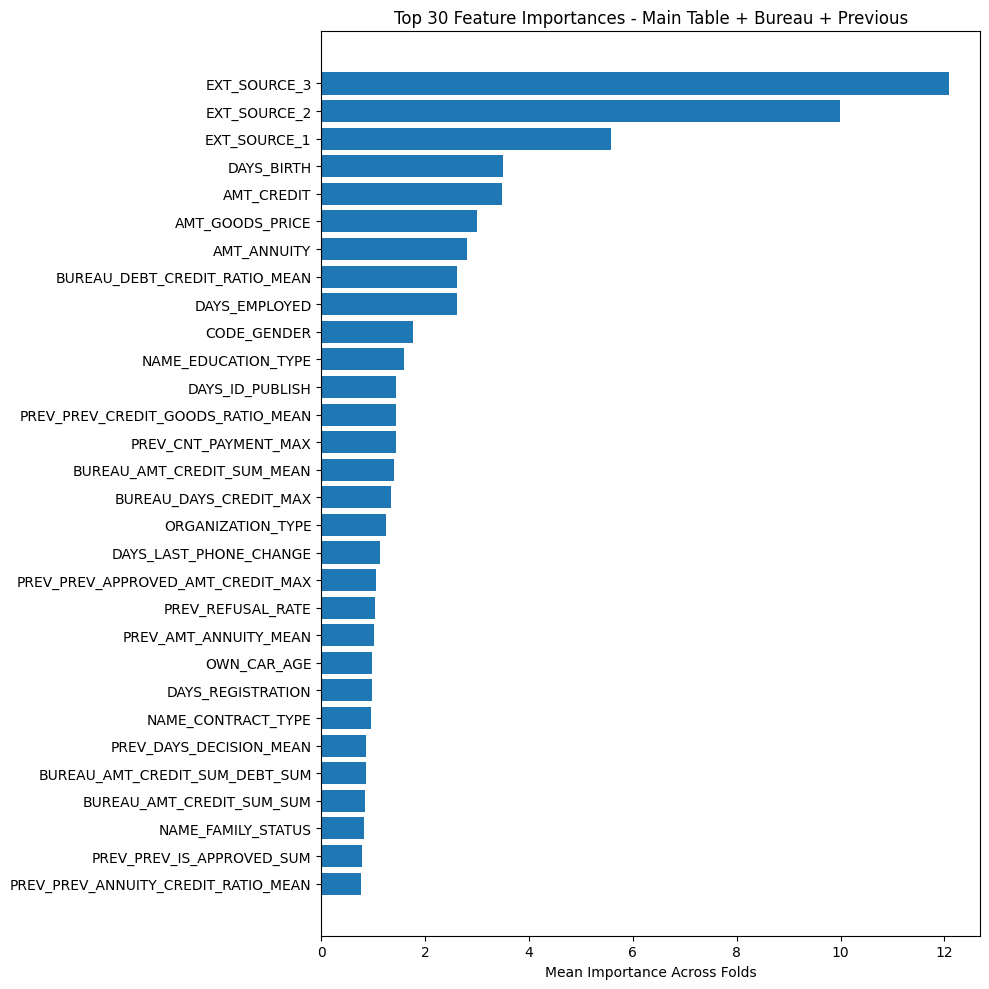

Figure saved to: C:\Coding\Home-Credit-Default-Risk\outputs\figures\model_v3_bureau_previous_feature_importance.png


In [8]:
plot_df = feature_importance.head(30).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 30 Feature Importances - Main Table + Bureau + Previous")
plt.xlabel("Mean Importance Across Folds")
plt.tight_layout()

fig_path = FIG_DIR / "model_v3_bureau_previous_feature_importance.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", fig_path)

In [9]:
report_lines = [
    "# Model V3 Results - Main Table + Bureau + Previous Application",
    "",
    "## Dataset",
    f"- Train shape: {train.shape}",
    f"- Test shape: {test.shape}",
    f"- Bureau feature table shape: {bureau_features.shape}",
    f"- Previous application feature table shape: {previous_features.shape}",
    f"- Final merged train feature matrix: {X.shape}",
    f"- Final merged test feature matrix: {X_test.shape}",
    f"- Number of categorical columns: {len(categorical_cols)}",
    f"- Number of numeric columns: {len(numeric_cols)}",
    f"- Number of bureau-derived columns used in model: {len(bureau_feature_names)}",
    f"- Number of previous-derived columns used in model: {len(prev_feature_names)}",
    "",
    "## Cross-validation",
    f"- Number of folds: {results['n_splits']}",
    f"- Fold AUC scores: {[round(score, 6) for score in results['fold_scores']]}",
    f"- Mean fold AUC: {np.mean(results['fold_scores']):.6f}",
    f"- OOF AUC: {results['overall_auc']:.6f}",
    "",
    "## Comparison",
    f"- Baseline mean fold AUC: {baseline_mean_auc:.6f}",
    f"- Baseline OOF AUC: {baseline_oof_auc:.6f}",
    f"- Bureau model mean fold AUC: {bureau_mean_auc:.6f}",
    f"- Bureau model OOF AUC: {bureau_oof_auc:.6f}",
    f"- OOF lift vs baseline: {results['overall_auc'] - baseline_oof_auc:.6f}",
    f"- OOF lift vs bureau-only model: {results['overall_auc'] - bureau_oof_auc:.6f}",
    "",
    "## Outputs",
    f"- Submission file: {submission_path}",
    f"- Feature importance figure: {fig_path}",
    "",
    "## Notes",
    "- This model adds previous_application aggregated features on top of the main table and bureau features.",
    "- The goal is to measure whether previous Home Credit application history improves discrimination beyond bureau-only history.",
]

report_text = "\n".join(report_lines)

report_path = REPORT_DIR / "model_v3_bureau_previous.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Report saved to:", report_path)

Report saved to: C:\Coding\Home-Credit-Default-Risk\outputs\reports\model_v3_bureau_previous.md


In [1]:
# %pip install duckdb pyarrow -q

import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.6f}".format)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, ID_COL

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

duckdb_temp_dir = PROCESSED_DATA_DIR / "_duckdb_temp"
duckdb_temp_dir.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
con.execute(f"PRAGMA temp_directory='{duckdb_temp_dir.as_posix()}';")
con.execute("PRAGMA threads=4;")

installments_path = (RAW_DATA_DIR / "installments_payments.csv").as_posix()
pos_path = (RAW_DATA_DIR / "POS_CASH_balance.csv").as_posix()
cc_path = (RAW_DATA_DIR / "credit_card_balance.csv").as_posix()

print("DuckDB ready")
print("Installments path:", installments_path)
print("POS path:", pos_path)
print("CC path:", cc_path)

DuckDB ready
Installments path: C:/Coding/Home-Credit-Default-Risk/data/raw/installments_payments.csv
POS path: C:/Coding/Home-Credit-Default-Risk/data/raw/POS_CASH_balance.csv
CC path: C:/Coding/Home-Credit-Default-Risk/data/raw/credit_card_balance.csv


In [2]:
train_ids = pd.read_csv(RAW_DATA_DIR / "application_train.csv", usecols=[ID_COL])
test_ids = pd.read_csv(RAW_DATA_DIR / "application_test.csv", usecols=[ID_COL])

base = pd.concat([train_ids, test_ids], axis=0, ignore_index=True)
base = base.drop_duplicates(subset=[ID_COL]).reset_index(drop=True)

print("Base shape:", base.shape)
display(base.head())

Base shape: (356255, 1)


,SK_ID_CURR
0,100002
1,100003
2,100004
3,100006
4,100007


In [3]:
con.execute(f"""
COPY (
    WITH src AS (
        SELECT
            SK_ID_CURR,
            SK_ID_PREV,
            NUM_INSTALMENT_VERSION,
            NUM_INSTALMENT_NUMBER,
            DAYS_INSTALMENT,
            DAYS_ENTRY_PAYMENT,
            AMT_INSTALMENT,
            AMT_PAYMENT,
            CASE
                WHEN AMT_INSTALMENT IS NULL OR AMT_INSTALMENT = 0 THEN NULL
                ELSE AMT_PAYMENT / AMT_INSTALMENT
            END AS INS_PAYMENT_RATIO,
            AMT_PAYMENT - AMT_INSTALMENT AS INS_PAYMENT_DIFF,
            GREATEST(DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT, 0) AS INS_DPD,
            GREATEST(DAYS_INSTALMENT - DAYS_ENTRY_PAYMENT, 0) AS INS_DBD,
            CASE WHEN DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT > 0 THEN 1 ELSE 0 END AS INS_IS_LATE,
            CASE WHEN DAYS_INSTALMENT - DAYS_ENTRY_PAYMENT > 0 THEN 1 ELSE 0 END AS INS_IS_EARLY,
            CASE WHEN AMT_PAYMENT < AMT_INSTALMENT THEN 1 ELSE 0 END AS INS_IS_UNDERPAID,
            CASE WHEN AMT_PAYMENT > AMT_INSTALMENT THEN 1 ELSE 0 END AS INS_IS_OVERPAID
        FROM read_csv_auto('{installments_path}', header=true)
    )
    SELECT
        SK_ID_CURR,
        COUNT(DISTINCT SK_ID_PREV) AS INS_SK_ID_PREV_NUNIQUE,
        COUNT(*) AS INS_RECORD_COUNT,
        COUNT(DISTINCT NUM_INSTALMENT_VERSION) AS INS_NUM_INSTALMENT_VERSION_NUNIQUE,
        MAX(NUM_INSTALMENT_NUMBER) AS INS_NUM_INSTALMENT_NUMBER_MAX,

        AVG(INS_DPD) AS INS_DPD_MEAN,
        MAX(INS_DPD) AS INS_DPD_MAX,
        SUM(INS_DPD) AS INS_DPD_SUM,

        AVG(INS_DBD) AS INS_DBD_MEAN,
        MAX(INS_DBD) AS INS_DBD_MAX,
        SUM(INS_DBD) AS INS_DBD_SUM,

        SUM(INS_IS_LATE) AS INS_LATE_COUNT,
        AVG(INS_IS_LATE) AS INS_LATE_RATIO,
        SUM(INS_IS_EARLY) AS INS_EARLY_COUNT,
        AVG(INS_IS_EARLY) AS INS_EARLY_RATIO,

        SUM(INS_IS_UNDERPAID) AS INS_UNDERPAID_COUNT,
        AVG(INS_IS_UNDERPAID) AS INS_UNDERPAID_RATIO,
        SUM(INS_IS_OVERPAID) AS INS_OVERPAID_COUNT,
        AVG(INS_IS_OVERPAID) AS INS_OVERPAID_RATIO,

        AVG(INS_PAYMENT_RATIO) AS INS_PAYMENT_RATIO_MEAN,
        MIN(INS_PAYMENT_RATIO) AS INS_PAYMENT_RATIO_MIN,
        MAX(INS_PAYMENT_RATIO) AS INS_PAYMENT_RATIO_MAX,

        AVG(INS_PAYMENT_DIFF) AS INS_PAYMENT_DIFF_MEAN,
        MIN(INS_PAYMENT_DIFF) AS INS_PAYMENT_DIFF_MIN,
        MAX(INS_PAYMENT_DIFF) AS INS_PAYMENT_DIFF_MAX,
        SUM(INS_PAYMENT_DIFF) AS INS_PAYMENT_DIFF_SUM,

        SUM(AMT_PAYMENT) AS INS_AMT_PAYMENT_SUM,
        AVG(AMT_PAYMENT) AS INS_AMT_PAYMENT_MEAN,
        SUM(AMT_INSTALMENT) AS INS_AMT_INSTALMENT_SUM,
        AVG(AMT_INSTALMENT) AS INS_AMT_INSTALMENT_MEAN,

        MIN(DAYS_INSTALMENT) AS INS_DAYS_INSTALMENT_MIN,
        MAX(DAYS_INSTALMENT) AS INS_DAYS_INSTALMENT_MAX,
        MIN(DAYS_ENTRY_PAYMENT) AS INS_DAYS_ENTRY_PAYMENT_MIN,
        MAX(DAYS_ENTRY_PAYMENT) AS INS_DAYS_ENTRY_PAYMENT_MAX,

        CASE
            WHEN SUM(AMT_INSTALMENT) IS NULL OR SUM(AMT_INSTALMENT) = 0 THEN NULL
            ELSE SUM(AMT_PAYMENT) / SUM(AMT_INSTALMENT)
        END AS INS_TOTAL_PAYMENT_TO_INSTALMENT_RATIO
    FROM src
    GROUP BY SK_ID_CURR
) TO '{(PROCESSED_DATA_DIR / "installments_features.parquet").as_posix()}'
(FORMAT PARQUET);
""")

print("Saved installments_features.parquet")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved installments_features.parquet


In [4]:
installments_features = pd.read_parquet(PROCESSED_DATA_DIR / "installments_features.parquet")
print("Installments features shape:", installments_features.shape)
display(installments_features.head())

Installments features shape: (339587, 35)


,SK_ID_CURR,INS_SK_ID_PREV_NUNIQUE,INS_RECORD_COUNT,INS_NUM_INSTALMENT_VERSION_NUNIQUE,INS_NUM_INSTALMENT_NUMBER_MAX,INS_DPD_MEAN,INS_DPD_MAX,INS_DPD_SUM,INS_DBD_MEAN,INS_DBD_MAX,INS_DBD_SUM,INS_LATE_COUNT,INS_LATE_RATIO,INS_EARLY_COUNT,INS_EARLY_RATIO,INS_UNDERPAID_COUNT,INS_UNDERPAID_RATIO,INS_OVERPAID_COUNT,INS_OVERPAID_RATIO,INS_PAYMENT_RATIO_MEAN,INS_PAYMENT_RATIO_MIN,INS_PAYMENT_RATIO_MAX,INS_PAYMENT_DIFF_MEAN,INS_PAYMENT_DIFF_MIN,INS_PAYMENT_DIFF_MAX,INS_PAYMENT_DIFF_SUM,INS_AMT_PAYMENT_SUM,INS_AMT_PAYMENT_MEAN,INS_AMT_INSTALMENT_SUM,INS_AMT_INSTALMENT_MEAN,INS_DAYS_INSTALMENT_MIN,INS_DAYS_INSTALMENT_MAX,INS_DAYS_ENTRY_PAYMENT_MIN,INS_DAYS_ENTRY_PAYMENT_MAX,INS_TOTAL_PAYMENT_TO_INSTALMENT_RATIO
0,145280,6,105,3,48,0.104762,4.000000,11.000000,6.695238,30.000000,703.000000,3.000000,0.028571,59.000000,0.561905,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,"839,176.785000","7,992.159857","839,176.785000","7,992.159857","-2,894.000000",-8.000000,"-2,903.000000",-12.000000,1.000000
1,198934,8,69,2,18,0.057971,3.000000,4.000000,13.913043,60.000000,960.000000,2.000000,0.028986,64.000000,0.927536,2.000000,0.028986,0.000000,0.000000,0.985507,0.059746,1.000000,-592.235870,"-38,422.800000",0.000000,"-40,864.275000","1,287,183.060000","18,654.826957","1,328,047.335000","19,247.062826","-1,810.000000",-6.000000,"-1,817.000000",-18.000000,0.969230
2,158712,1,14,1,12,2.285714,17.000000,32.000000,10.142857,15.000000,142.000000,2.000000,0.142857,12.000000,0.857143,4.000000,0.285714,0.000000,0.000000,0.857143,0.000023,1.000000,-838.202143,"-5,867.280000",0.000000,"-11,734.830000","70,404.345000","5,028.881786","82,139.175000","5,867.083929",-498.000000,-168.000000,-510.000000,-179.000000,0.857135
3,191933,3,160,2,106,1.893750,30.000000,303.000000,4.843750,33.000000,775.000000,19.000000,0.118750,64.000000,0.400000,36.000000,0.225000,0.000000,0.000000,0.887500,0.000050,1.000000,-808.478156,"-22,292.685000",0.000000,"-129,356.505000","737,816.130000","4,611.350812","867,172.635000","5,419.828969","-2,919.000000",-15.000000,"-2,919.000000",-15.000000,0.850830
4,144004,2,10,2,6,0.000000,0.000000,0.000000,12.300000,26.000000,123.000000,0.000000,0.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,"313,822.395000","31,382.239500","313,822.395000","31,382.239500","-1,003.000000",-551.000000,"-1,012.000000",-565.000000,1.000000


In [5]:
con.execute(f"""
COPY (
    SELECT
        SK_ID_CURR,
        COUNT(DISTINCT SK_ID_PREV) AS POS_SK_ID_PREV_NUNIQUE,
        COUNT(*) AS POS_RECORD_COUNT,

        MIN(MONTHS_BALANCE) AS POS_MONTHS_BALANCE_MIN,
        MAX(MONTHS_BALANCE) AS POS_MONTHS_BALANCE_MAX,
        COUNT(MONTHS_BALANCE) AS POS_MONTHS_BALANCE_SIZE,

        AVG(CNT_INSTALMENT) AS POS_CNT_INSTALMENT_MEAN,
        MAX(CNT_INSTALMENT) AS POS_CNT_INSTALMENT_MAX,
        AVG(CNT_INSTALMENT_FUTURE) AS POS_CNT_INSTALMENT_FUTURE_MEAN,
        MAX(CNT_INSTALMENT_FUTURE) AS POS_CNT_INSTALMENT_FUTURE_MAX,

        AVG(SK_DPD) AS POS_SK_DPD_MEAN,
        MAX(SK_DPD) AS POS_SK_DPD_MAX,
        AVG(SK_DPD_DEF) AS POS_SK_DPD_DEF_MEAN,
        MAX(SK_DPD_DEF) AS POS_SK_DPD_DEF_MAX,

        SUM(CASE WHEN SK_DPD > 0 THEN 1 ELSE 0 END) AS POS_DPD_COUNT,
        AVG(CASE WHEN SK_DPD > 0 THEN 1.0 ELSE 0.0 END) AS POS_DPD_RATIO,

        SUM(CASE WHEN SK_DPD_DEF > 0 THEN 1 ELSE 0 END) AS POS_DPD_DEF_COUNT,
        AVG(CASE WHEN SK_DPD_DEF > 0 THEN 1.0 ELSE 0.0 END) AS POS_DPD_DEF_RATIO,

        SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Active' THEN 1 ELSE 0 END) AS POS_STATUS_ACTIVE_COUNT,
        SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Completed' THEN 1 ELSE 0 END) AS POS_STATUS_COMPLETED_COUNT,
        SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Signed' THEN 1 ELSE 0 END) AS POS_STATUS_SIGNED_COUNT,
        SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Demand' THEN 1 ELSE 0 END) AS POS_STATUS_DEMAND_COUNT,

        AVG(CASE WHEN NAME_CONTRACT_STATUS = 'Active' THEN 1.0 ELSE 0.0 END) AS POS_STATUS_ACTIVE_RATIO,
        AVG(CASE WHEN NAME_CONTRACT_STATUS = 'Completed' THEN 1.0 ELSE 0.0 END) AS POS_STATUS_COMPLETED_RATIO,
        AVG(CASE WHEN NAME_CONTRACT_STATUS = 'Signed' THEN 1.0 ELSE 0.0 END) AS POS_STATUS_SIGNED_RATIO,
        AVG(CASE WHEN NAME_CONTRACT_STATUS = 'Demand' THEN 1.0 ELSE 0.0 END) AS POS_STATUS_DEMAND_RATIO
    FROM read_csv_auto('{pos_path}', header=true)
    GROUP BY SK_ID_CURR
) TO '{(PROCESSED_DATA_DIR / "pos_cash_features.parquet").as_posix()}'
(FORMAT PARQUET);
""")

print("Saved pos_cash_features.parquet")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved pos_cash_features.parquet


In [6]:
pos_features = pd.read_parquet(PROCESSED_DATA_DIR / "pos_cash_features.parquet")
print("POS features shape:", pos_features.shape)
display(pos_features.head())

POS features shape: (337252, 26)


,SK_ID_CURR,POS_SK_ID_PREV_NUNIQUE,POS_RECORD_COUNT,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_SIZE,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_MAX,POS_DPD_COUNT,POS_DPD_RATIO,POS_DPD_DEF_COUNT,POS_DPD_DEF_RATIO,POS_STATUS_ACTIVE_COUNT,POS_STATUS_COMPLETED_COUNT,POS_STATUS_SIGNED_COUNT,POS_STATUS_DEMAND_COUNT,POS_STATUS_ACTIVE_RATIO,POS_STATUS_COMPLETED_RATIO,POS_STATUS_SIGNED_RATIO,POS_STATUS_DEMAND_RATIO
0,121756,7,87,-58,-2,87,17.344828,24.000000,11.091954,24.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,82.000000,5.000000,0.000000,0.000000,0.942529,0.057471,0.000000,0.000000
1,454817,6,57,-96,-12,57,9.614035,12.000000,4.122807,12.000000,2.473684,67,0.087719,5,6.000000,0.105263,1.000000,0.017544,49.000000,6.000000,2.000000,0.000000,0.859649,0.105263,0.035088,0.000000
2,307337,6,67,-64,-2,67,20.611940,36.000000,13.731343,36.000000,0.776119,18,0.000000,0,3.000000,0.044776,0.000000,0.000000,61.000000,5.000000,1.000000,0.000000,0.910448,0.074627,0.014925,0.000000
3,183913,6,67,-96,-3,67,11.477612,18.000000,5.761194,18.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,62.000000,5.000000,0.000000,0.000000,0.925373,0.074627,0.000000,0.000000
4,112560,3,35,-72,-29,35,12.800000,18.000000,7.085714,18.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,33.000000,2.000000,0.000000,0.000000,0.942857,0.057143,0.000000,0.000000


In [7]:
con.execute(f"""
COPY (
    WITH src AS (
        SELECT
            SK_ID_CURR,
            SK_ID_PREV,
            MONTHS_BALANCE,
            AMT_BALANCE,
            AMT_CREDIT_LIMIT_ACTUAL,
            AMT_DRAWINGS_CURRENT,
            AMT_PAYMENT_CURRENT,
            AMT_PAYMENT_TOTAL_CURRENT,
            AMT_INST_MIN_REGULARITY,
            CNT_DRAWINGS_CURRENT,
            CNT_DRAWINGS_ATM_CURRENT,
            CNT_DRAWINGS_POS_CURRENT,
            CNT_INSTALMENT_MATURE_CUM,
            SK_DPD,
            SK_DPD_DEF,
            NAME_CONTRACT_STATUS,

            CASE
                WHEN AMT_CREDIT_LIMIT_ACTUAL IS NULL OR AMT_CREDIT_LIMIT_ACTUAL = 0 THEN NULL
                ELSE AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL
            END AS CC_BALANCE_LIMIT_RATIO,

            CASE
                WHEN AMT_CREDIT_LIMIT_ACTUAL IS NULL OR AMT_CREDIT_LIMIT_ACTUAL = 0 THEN NULL
                ELSE AMT_DRAWINGS_CURRENT / AMT_CREDIT_LIMIT_ACTUAL
            END AS CC_DRAWINGS_LIMIT_RATIO,

            CASE
                WHEN AMT_INST_MIN_REGULARITY IS NULL OR AMT_INST_MIN_REGULARITY = 0 THEN NULL
                ELSE AMT_PAYMENT_CURRENT / AMT_INST_MIN_REGULARITY
            END AS CC_PAYMENT_MIN_RATIO,

            CASE
                WHEN AMT_BALANCE IS NULL OR AMT_BALANCE = 0 THEN NULL
                ELSE AMT_PAYMENT_TOTAL_CURRENT / AMT_BALANCE
            END AS CC_TOTAL_PAYMENT_BALANCE_RATIO,

            CASE WHEN SK_DPD > 0 THEN 1 ELSE 0 END AS CC_IS_DPD,
            CASE WHEN SK_DPD_DEF > 0 THEN 1 ELSE 0 END AS CC_IS_DPD_DEF,
            CASE WHEN AMT_BALANCE > 0 THEN 1 ELSE 0 END AS CC_BALANCE_POSITIVE,
            CASE WHEN AMT_PAYMENT_CURRENT < AMT_INST_MIN_REGULARITY THEN 1 ELSE 0 END AS CC_PAYMENT_LESS_THAN_MIN
        FROM read_csv_auto('{cc_path}', header=true)
    )
    SELECT
        SK_ID_CURR,
        COUNT(DISTINCT SK_ID_PREV) AS CC_SK_ID_PREV_NUNIQUE,
        COUNT(*) AS CC_RECORD_COUNT,

        MIN(MONTHS_BALANCE) AS CC_MONTHS_BALANCE_MIN,
        MAX(MONTHS_BALANCE) AS CC_MONTHS_BALANCE_MAX,
        COUNT(MONTHS_BALANCE) AS CC_MONTHS_BALANCE_SIZE,

        AVG(AMT_BALANCE) AS CC_AMT_BALANCE_MEAN,
        MAX(AMT_BALANCE) AS CC_AMT_BALANCE_MAX,
        SUM(AMT_BALANCE) AS CC_AMT_BALANCE_SUM,

        AVG(AMT_CREDIT_LIMIT_ACTUAL) AS CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,
        MAX(AMT_CREDIT_LIMIT_ACTUAL) AS CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,

        AVG(CC_BALANCE_LIMIT_RATIO) AS CC_BALANCE_LIMIT_RATIO_MEAN,
        MAX(CC_BALANCE_LIMIT_RATIO) AS CC_BALANCE_LIMIT_RATIO_MAX,

        AVG(AMT_DRAWINGS_CURRENT) AS CC_AMT_DRAWINGS_CURRENT_MEAN,
        MAX(AMT_DRAWINGS_CURRENT) AS CC_AMT_DRAWINGS_CURRENT_MAX,
        SUM(AMT_DRAWINGS_CURRENT) AS CC_AMT_DRAWINGS_CURRENT_SUM,

        AVG(CC_DRAWINGS_LIMIT_RATIO) AS CC_DRAWINGS_LIMIT_RATIO_MEAN,
        MAX(CC_DRAWINGS_LIMIT_RATIO) AS CC_DRAWINGS_LIMIT_RATIO_MAX,

        AVG(AMT_PAYMENT_CURRENT) AS CC_AMT_PAYMENT_CURRENT_MEAN,
        MAX(AMT_PAYMENT_CURRENT) AS CC_AMT_PAYMENT_CURRENT_MAX,
        SUM(AMT_PAYMENT_CURRENT) AS CC_AMT_PAYMENT_CURRENT_SUM,

        AVG(AMT_PAYMENT_TOTAL_CURRENT) AS CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,
        MAX(AMT_PAYMENT_TOTAL_CURRENT) AS CC_AMT_PAYMENT_TOTAL_CURRENT_MAX,
        SUM(AMT_PAYMENT_TOTAL_CURRENT) AS CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,

        AVG(AMT_INST_MIN_REGULARITY) AS CC_AMT_INST_MIN_REGULARITY_MEAN,
        MAX(AMT_INST_MIN_REGULARITY) AS CC_AMT_INST_MIN_REGULARITY_MAX,

        AVG(CC_PAYMENT_MIN_RATIO) AS CC_PAYMENT_MIN_RATIO_MEAN,
        MAX(CC_PAYMENT_MIN_RATIO) AS CC_PAYMENT_MIN_RATIO_MAX,

        AVG(CC_TOTAL_PAYMENT_BALANCE_RATIO) AS CC_TOTAL_PAYMENT_BALANCE_RATIO_MEAN,
        MAX(CC_TOTAL_PAYMENT_BALANCE_RATIO) AS CC_TOTAL_PAYMENT_BALANCE_RATIO_MAX,

        AVG(CNT_DRAWINGS_CURRENT) AS CC_CNT_DRAWINGS_CURRENT_MEAN,
        MAX(CNT_DRAWINGS_CURRENT) AS CC_CNT_DRAWINGS_CURRENT_MAX,
        AVG(CNT_DRAWINGS_ATM_CURRENT) AS CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,
        AVG(CNT_DRAWINGS_POS_CURRENT) AS CC_CNT_DRAWINGS_POS_CURRENT_MEAN,

        AVG(CNT_INSTALMENT_MATURE_CUM) AS CC_CNT_INSTALMENT_MATURE_CUM_MEAN,
        MAX(CNT_INSTALMENT_MATURE_CUM) AS CC_CNT_INSTALMENT_MATURE_CUM_MAX,

        AVG(SK_DPD) AS CC_SK_DPD_MEAN,
        MAX(SK_DPD) AS CC_SK_DPD_MAX,
        AVG(SK_DPD_DEF) AS CC_SK_DPD_DEF_MEAN,
        MAX(SK_DPD_DEF) AS CC_SK_DPD_DEF_MAX,

        SUM(CC_IS_DPD) AS CC_DPD_COUNT,
        AVG(CC_IS_DPD) AS CC_DPD_RATIO,
        SUM(CC_IS_DPD_DEF) AS CC_DPD_DEF_COUNT,
        AVG(CC_IS_DPD_DEF) AS CC_DPD_DEF_RATIO,

        SUM(CC_BALANCE_POSITIVE) AS CC_BALANCE_POSITIVE_COUNT,
        AVG(CC_BALANCE_POSITIVE) AS CC_BALANCE_POSITIVE_RATIO,

        SUM(CC_PAYMENT_LESS_THAN_MIN) AS CC_PAYMENT_LESS_THAN_MIN_COUNT,
        AVG(CC_PAYMENT_LESS_THAN_MIN) AS CC_PAYMENT_LESS_THAN_MIN_RATIO,

        SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Active' THEN 1 ELSE 0 END) AS CC_STATUS_ACTIVE_COUNT,
        SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Completed' THEN 1 ELSE 0 END) AS CC_STATUS_COMPLETED_COUNT,
        SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Demand' THEN 1 ELSE 0 END) AS CC_STATUS_DEMAND_COUNT,
        SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Signed' THEN 1 ELSE 0 END) AS CC_STATUS_SIGNED_COUNT,

        AVG(CASE WHEN NAME_CONTRACT_STATUS = 'Active' THEN 1.0 ELSE 0.0 END) AS CC_STATUS_ACTIVE_RATIO,
        AVG(CASE WHEN NAME_CONTRACT_STATUS = 'Completed' THEN 1.0 ELSE 0.0 END) AS CC_STATUS_COMPLETED_RATIO,
        AVG(CASE WHEN NAME_CONTRACT_STATUS = 'Demand' THEN 1.0 ELSE 0.0 END) AS CC_STATUS_DEMAND_RATIO,
        AVG(CASE WHEN NAME_CONTRACT_STATUS = 'Signed' THEN 1.0 ELSE 0.0 END) AS CC_STATUS_SIGNED_RATIO
    FROM src
    GROUP BY SK_ID_CURR
) TO '{(PROCESSED_DATA_DIR / "credit_card_features.parquet").as_posix()}'
(FORMAT PARQUET);
""")

print("Saved credit_card_features.parquet")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved credit_card_features.parquet


In [8]:
cc_features = pd.read_parquet(PROCESSED_DATA_DIR / "credit_card_features.parquet")
print("Credit card features shape:", cc_features.shape)
display(cc_features.head())

Credit card features shape: (103558, 56)


,SK_ID_CURR,CC_SK_ID_PREV_NUNIQUE,CC_RECORD_COUNT,CC_MONTHS_BALANCE_MIN,CC_MONTHS_BALANCE_MAX,CC_MONTHS_BALANCE_SIZE,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_BALANCE_SUM,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_BALANCE_LIMIT_RATIO_MEAN,CC_BALANCE_LIMIT_RATIO_MAX,CC_AMT_DRAWINGS_CURRENT_MEAN,CC_AMT_DRAWINGS_CURRENT_MAX,CC_AMT_DRAWINGS_CURRENT_SUM,CC_DRAWINGS_LIMIT_RATIO_MEAN,CC_DRAWINGS_LIMIT_RATIO_MAX,CC_AMT_PAYMENT_CURRENT_MEAN,CC_AMT_PAYMENT_CURRENT_MAX,CC_AMT_PAYMENT_CURRENT_SUM,CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,CC_AMT_PAYMENT_TOTAL_CURRENT_MAX,CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,CC_AMT_INST_MIN_REGULARITY_MEAN,CC_AMT_INST_MIN_REGULARITY_MAX,CC_PAYMENT_MIN_RATIO_MEAN,CC_PAYMENT_MIN_RATIO_MAX,CC_TOTAL_PAYMENT_BALANCE_RATIO_MEAN,CC_TOTAL_PAYMENT_BALANCE_RATIO_MAX,CC_CNT_DRAWINGS_CURRENT_MEAN,CC_CNT_DRAWINGS_CURRENT_MAX,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,CC_CNT_DRAWINGS_POS_CURRENT_MEAN,CC_CNT_INSTALMENT_MATURE_CUM_MEAN,CC_CNT_INSTALMENT_MATURE_CUM_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_MAX,CC_SK_DPD_DEF_MEAN,CC_SK_DPD_DEF_MAX,CC_DPD_COUNT,CC_DPD_RATIO,CC_DPD_DEF_COUNT,CC_DPD_DEF_RATIO,CC_BALANCE_POSITIVE_COUNT,CC_BALANCE_POSITIVE_RATIO,CC_PAYMENT_LESS_THAN_MIN_COUNT,CC_PAYMENT_LESS_THAN_MIN_RATIO,CC_STATUS_ACTIVE_COUNT,CC_STATUS_COMPLETED_COUNT,CC_STATUS_DEMAND_COUNT,CC_STATUS_SIGNED_COUNT,CC_STATUS_ACTIVE_RATIO,CC_STATUS_COMPLETED_RATIO,CC_STATUS_DEMAND_RATIO,CC_STATUS_SIGNED_RATIO
0,205087,1,31,-32,-2,31,"33,941.543226","184,911.480000","1,052,187.840000","162,580.645161",180000,0.191650,1.027286,"5,804.129032","179,928.000000","179,928.000000",0.032245,0.999600,"17,043.991071","22,500.000000","238,615.875000","7,697.286290","22,500.000000","238,615.875000","2,150.483400","9,351.225000",25.078029,222.466667,114.250242,"1,253.333333",0.032258,1,0.000000,0.000000,3.960000,11.000000,0.225806,7,0.225806,7,1.000000,0.032258,1.000000,0.032258,11.000000,0.354839,0.000000,0.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
1,328431,1,60,-61,-2,60,0.000000,0.000000,0.000000,"78,750.000000",90000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0,NaN,NaN,0.000000,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
2,326876,1,15,-15,-1,15,0.000000,0.000000,0.000000,"675,000.000000",675000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0,NaN,NaN,0.000000,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
3,147249,1,96,-96,-1,96,"9,140.360625","89,298.675000","877,474.620000","81,093.750000",90000,0.101560,0.992208,468.750000,"22,500.000000","45,000.000000",0.005208,0.250000,"2,434.478906","45,000.000000","233,709.975000","1,821.796875","45,000.000000","174,892.500000","1,071.104062","5,400.000000",2.403221,12.286000,3.613335,63.884157,0.020833,1,0.020833,0.000000,34.708333,37.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,19.000000,0.197917,0.000000,0.000000,96.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
4,296309,1,95,-95,-1,95,"9,326.765368","69,563.385000","886,042.710000","22,736.842105",67500,0.410205,1.030569,"1,710.000000","67,500.000000","162,450.000000",0.075208,1.000000,"2,161.035000","45,000.000000","205,298.325000","2,147.875105","45,000.000000","204,048.135000",819.947967,"3,375.000000",2.602466,13.333333,7.752233,93.882227,0.105263,3,0.108696,0.000000,20.637363,24.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,24.000000,0.252632,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000


In [9]:
payment_history_features = (
    base
    .merge(installments_features, on=ID_COL, how="left")
    .merge(pos_features, on=ID_COL, how="left")
    .merge(cc_features, on=ID_COL, how="left")
)

print("Combined payment history features shape:", payment_history_features.shape)
print("Unique key:", payment_history_features[ID_COL].is_unique)

display(payment_history_features.head())

Combined payment history features shape: (356255, 115)
Unique key: True


,SK_ID_CURR,INS_SK_ID_PREV_NUNIQUE,INS_RECORD_COUNT,INS_NUM_INSTALMENT_VERSION_NUNIQUE,INS_NUM_INSTALMENT_NUMBER_MAX,INS_DPD_MEAN,INS_DPD_MAX,INS_DPD_SUM,INS_DBD_MEAN,INS_DBD_MAX,INS_DBD_SUM,INS_LATE_COUNT,INS_LATE_RATIO,INS_EARLY_COUNT,INS_EARLY_RATIO,INS_UNDERPAID_COUNT,INS_UNDERPAID_RATIO,INS_OVERPAID_COUNT,INS_OVERPAID_RATIO,INS_PAYMENT_RATIO_MEAN,INS_PAYMENT_RATIO_MIN,INS_PAYMENT_RATIO_MAX,INS_PAYMENT_DIFF_MEAN,INS_PAYMENT_DIFF_MIN,INS_PAYMENT_DIFF_MAX,INS_PAYMENT_DIFF_SUM,INS_AMT_PAYMENT_SUM,INS_AMT_PAYMENT_MEAN,INS_AMT_INSTALMENT_SUM,INS_AMT_INSTALMENT_MEAN,INS_DAYS_INSTALMENT_MIN,INS_DAYS_INSTALMENT_MAX,INS_DAYS_ENTRY_PAYMENT_MIN,INS_DAYS_ENTRY_PAYMENT_MAX,INS_TOTAL_PAYMENT_TO_INSTALMENT_RATIO,POS_SK_ID_PREV_NUNIQUE,POS_RECORD_COUNT,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_SIZE,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_MAX,POS_DPD_COUNT,POS_DPD_RATIO,POS_DPD_DEF_COUNT,POS_DPD_DEF_RATIO,POS_STATUS_ACTIVE_COUNT,POS_STATUS_COMPLETED_COUNT,POS_STATUS_SIGNED_COUNT,POS_STATUS_DEMAND_COUNT,POS_STATUS_ACTIVE_RATIO,POS_STATUS_COMPLETED_RATIO,POS_STATUS_SIGNED_RATIO,POS_STATUS_DEMAND_RATIO,CC_SK_ID_PREV_NUNIQUE,CC_RECORD_COUNT,CC_MONTHS_BALANCE_MIN,CC_MONTHS_BALANCE_MAX,CC_MONTHS_BALANCE_SIZE,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_BALANCE_SUM,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_BALANCE_LIMIT_RATIO_MEAN,CC_BALANCE_LIMIT_RATIO_MAX,CC_AMT_DRAWINGS_CURRENT_MEAN,CC_AMT_DRAWINGS_CURRENT_MAX,CC_AMT_DRAWINGS_CURRENT_SUM,CC_DRAWINGS_LIMIT_RATIO_MEAN,CC_DRAWINGS_LIMIT_RATIO_MAX,CC_AMT_PAYMENT_CURRENT_MEAN,CC_AMT_PAYMENT_CURRENT_MAX,CC_AMT_PAYMENT_CURRENT_SUM,CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,CC_AMT_PAYMENT_TOTAL_CURRENT_MAX,CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,CC_AMT_INST_MIN_REGULARITY_MEAN,CC_AMT_INST_MIN_REGULARITY_MAX,CC_PAYMENT_MIN_RATIO_MEAN,CC_PAYMENT_MIN_RATIO_MAX,CC_TOTAL_PAYMENT_BALANCE_RATIO_MEAN,CC_TOTAL_PAYMENT_BALANCE_RATIO_MAX,CC_CNT_DRAWINGS_CURRENT_MEAN,CC_CNT_DRAWINGS_CURRENT_MAX,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,CC_CNT_DRAWINGS_POS_CURRENT_MEAN,CC_CNT_INSTALMENT_MATURE_CUM_MEAN,CC_CNT_INSTALMENT_MATURE_CUM_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_MAX,CC_SK_DPD_DEF_MEAN,CC_SK_DPD_DEF_MAX,CC_DPD_COUNT,CC_DPD_RATIO,CC_DPD_DEF_COUNT,CC_DPD_DEF_RATIO,CC_BALANCE_POSITIVE_COUNT,CC_BALANCE_POSITIVE_RATIO,CC_PAYMENT_LESS_THAN_MIN_COUNT,CC_PAYMENT_LESS_THAN_MIN_RATIO,CC_STATUS_ACTIVE_COUNT,CC_STATUS_COMPLETED_COUNT,CC_STATUS_DEMAND_COUNT,CC_STATUS_SIGNED_COUNT,CC_STATUS_ACTIVE_RATIO,CC_STATUS_COMPLETED_RATIO,CC_STATUS_DEMAND_RATIO,CC_STATUS_SIGNED_RATIO
0,100002,1.000000,19.000000,2.000000,19.000000,0.000000,0.000000,0.000000,20.421053,31.000000,388.000000,0.000000,0.000000,19.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,"219,625.695000","11,559.247105","219,625.695000","11,559.247105",-565.000000,-25.000000,-587.000000,-49.000000,1.000000,1.000000,19.000000,-19.000000,-1.000000,19.000000,24.000000,24.000000,15.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,3.000000,25.000000,2.000000,12.000000,0.000000,0.000000,0.000000,7.160000,14.000000,179.000000,0.000000,0.000000,25.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,"1,618,864.650000","64,754.586000","1,618,864.650000","64,754.586000","-2,310.000000",-536.000000,"-2,324.000000",-544.000000,1.000000,3.000000,28.000000,-77.000000,-18.000000,28.000000,10.107143,12.000000,5.785714,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.

In [10]:
payment_history_features.to_parquet(
    PROCESSED_DATA_DIR / "payment_history_features.parquet",
    index=False
)

print("Saved:", PROCESSED_DATA_DIR / "payment_history_features.parquet")

Saved: C:\Coding\Home-Credit-Default-Risk\data\processed\payment_history_features.parquet


In [11]:
feature_cols = [c for c in payment_history_features.columns if c != ID_COL]

print("Number of payment-history features:", len(feature_cols))
print()

display(
    payment_history_features[feature_cols]
    .isnull()
    .mean()
    .sort_values(ascending=False)
    .head(30)
)

Number of payment-history features: 114



CC_PAYMENT_MIN_RATIO_MAX              0.803837
CC_PAYMENT_MIN_RATIO_MEAN             0.803837
CC_TOTAL_PAYMENT_BALANCE_RATIO_MAX    0.802855
CC_TOTAL_PAYMENT_BALANCE_RATIO_MEAN   0.802855
CC_AMT_PAYMENT_CURRENT_SUM            0.797561
CC_AMT_PAYMENT_CURRENT_MEAN           0.797561
CC_AMT_PAYMENT_CURRENT_MAX            0.797561
CC_CNT_DRAWINGS_ATM_CURRENT_MEAN      0.797353
CC_CNT_DRAWINGS_POS_CURRENT_MEAN      0.797353
CC_DRAWINGS_LIMIT_RATIO_MAX           0.712439
CC_BALANCE_LIMIT_RATIO_MEAN           0.712439
CC_BALANCE_LIMIT_RATIO_MAX            0.712439
CC_DRAWINGS_LIMIT_RATIO_MEAN          0.712439
CC_MONTHS_BALANCE_MIN                 0.709315
CC_AMT_INST_MIN_REGULARITY_MAX        0.709315
CC_AMT_INST_MIN_REGULARITY_MEAN       0.709315
CC_AMT_PAYMENT_TOTAL_CURRENT_SUM      0.709315
CC_AMT_PAYMENT_TOTAL_CURRENT_MAX      0.709315
CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN     0.709315
CC_MONTHS_BALANCE_SIZE                0.709315
CC_AMT_BALANCE_MEAN                   0.709315
CC_MONTHS_BAL

In [12]:
check_cols = [
    "INS_RECORD_COUNT",
    "INS_LATE_RATIO",
    "INS_UNDERPAID_RATIO",
    "INS_TOTAL_PAYMENT_TO_INSTALMENT_RATIO",
    "POS_RECORD_COUNT",
    "POS_DPD_RATIO",
    "POS_DPD_DEF_RATIO",
    "CC_RECORD_COUNT",
    "CC_BALANCE_LIMIT_RATIO_MEAN",
    "CC_PAYMENT_MIN_RATIO_MEAN",
    "CC_DPD_RATIO",
]

existing_check_cols = [c for c in check_cols if c in payment_history_features.columns]
display(payment_history_features[existing_check_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
INS_RECORD_COUNT,"339,587.000000",40.064552,41.053343,1.000000,12.000000,25.000000,51.000000,372.000000
INS_LATE_RATIO,"339,587.000000",0.074385,0.114490,0.000000,0.000000,0.017857,0.109375,1.000000
INS_UNDERPAID_RATIO,"339,587.000000",0.082631,0.148284,0.000000,0.000000,0.000000,0.105263,1.000000
INS_TOTAL_PAYMENT_TO_INSTALMENT_RATIO,"339,575.000000",0.993408,0.136955,0.133538,0.962445,1.000000,1.000000,5.485141
POS_RECORD_COUNT,"337,252.000000",29.655445,24.531971,1.000000,12.000000,22.000000,39.000000,295.000000
POS_DPD_RATIO,"337,252.000000",0.021046,0.078553,0.000000,0.000000,0.000000,0.000000,1.000000
POS_DPD_DEF_RATIO,"337,252.000000",0.009903,0.039230,0.000000,0.000000,0.000000,0.000000,1.000000
CC_RECORD_COUNT,"103,558.000000",37.083683,33.483627,1.000000,10.000000,22.000000,75.000000,192.000000
CC_BALANCE_LIMIT_RATIO_MEAN,"102,445.000000",0.320573,0.324382,-0.084848,0.000000,0.241313,0.583274,2.138790
CC_PAYMENT_MIN_RATIO_MEAN,"69,884.000000",18.715104,"1,886.981209",0.000000,1.411504,2.398907,5.010565,"496,093.080083"


In [1]:
# %pip install catboost pyarrow -q

import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.6f}".format)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import (
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURES_DIR,
    REPORTS_DIR,
    SUBMISSIONS_DIR,
    TARGET_COL,
    ID_COL,
    RANDOM_STATE,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
processed_files = sorted([p.name for p in PROCESSED_DATA_DIR.glob("*.parquet")])
print("Processed parquet files:")
for f in processed_files:
    print("-", f)

def find_first_existing(candidates):
    for name in candidates:
        path = PROCESSED_DATA_DIR / name
        if path.exists():
            return path
    raise FileNotFoundError(f"None of these files were found: {candidates}")

bureau_path = find_first_existing([
    "bureau_features.parquet"
])

previous_path = find_first_existing([
    "previous_application_features.parquet",
    "previous_features.parquet"
])

payment_path = find_first_existing([
    "payment_history_features.parquet"
])

print()
print("Using files:")
print("bureau   :", bureau_path.name)
print("previous :", previous_path.name)
print("payments :", payment_path.name)

Processed parquet files:
- bureau_features.parquet
- credit_card_features.parquet
- installments_features.parquet
- payment_history_features.parquet
- pos_cash_features.parquet
- previous_application_features.parquet

Using files:
bureau   : bureau_features.parquet
previous : previous_application_features.parquet
payments : payment_history_features.parquet


In [4]:
train = pd.read_csv(RAW_DATA_DIR / "application_train.csv")
test = pd.read_csv(RAW_DATA_DIR / "application_test.csv")

bureau_features = pd.read_parquet(bureau_path)
previous_features = pd.read_parquet(previous_path)
payment_features = pd.read_parquet(payment_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Bureau features shape:", bureau_features.shape)
print("Previous features shape:", previous_features.shape)
print("Payment features shape:", payment_features.shape)

Train shape: (307511, 122)
Test shape: (48744, 121)
Bureau features shape: (356255, 37)
Previous features shape: (356255, 39)
Payment features shape: (356255, 115)


In [5]:
train_model = (
    train
    .merge(bureau_features, on=ID_COL, how="left")
    .merge(previous_features, on=ID_COL, how="left")
    .merge(payment_features, on=ID_COL, how="left")
)

test_model = (
    test
    .merge(bureau_features, on=ID_COL, how="left")
    .merge(previous_features, on=ID_COL, how="left")
    .merge(payment_features, on=ID_COL, how="left")
)

print("Merged train shape:", train_model.shape)
print("Merged test shape:", test_model.shape)

display(train_model.head())

Merged train shape: (307511, 310)
Merged test shape: (48744, 309)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,...,INS_UNDERPAID_COUNT,INS_UNDERPAID_RATIO,INS_OVERPAID_COUNT,INS_OVERPAID_RATIO,INS_PAYMENT_RATIO_MEAN,INS_PAYMENT_RATIO_MIN,INS_PAYMENT_RATIO_MAX,INS_PAYMENT_DIFF_MEAN,INS_PAYMENT_DIFF_MIN,INS_PAYMENT_DIFF_MAX,INS_PAYMENT_DIFF_SUM,INS_AMT_PAYMENT_SUM,INS_AMT_PAYMENT_MEAN,INS_AMT_INSTALMENT_SUM,INS_AMT_INSTALMENT_MEAN,INS_DAYS_INSTALMENT_MIN,INS_DAYS_INSTALMENT_MAX,INS_DAYS_ENTRY_PAYMENT_MIN,INS_DAYS_ENTRY_PAYMENT_MAX,INS_TOTAL_PAYMENT_TO_INSTALMENT_RATIO,POS_SK_ID_PREV_NUNIQUE,POS_RECORD_COUNT,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_SIZE,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_MAX,POS_DPD_COUNT,POS_DPD_RATIO,POS_DPD_DEF_COUNT,POS_DPD_DEF_RATIO,POS_STATUS_ACTIVE_COUNT,POS_STATUS_COMPLETED_COUNT,POS_STATUS_SIGNED_COUNT,POS_STATUS_DEMAND_COUNT,POS_STATUS_ACTIVE_RATIO,POS_STATUS_COMPLETED_RATIO,POS_STATUS_SIGNED_RATIO,POS_STATUS_DEMAND_RATIO,CC_SK_ID_PREV_NUNIQUE,CC_RECORD_COUNT,CC_MONTHS_BALANCE_MIN,CC_MONTHS_BALANCE_MAX,CC_MONTHS_BALANCE_SIZE,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_BALANCE_SUM,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_BALANCE_LIMIT_RATIO_MEAN,CC_BALANCE_LIMIT_RATIO_MAX,CC_AMT_DRAWINGS_CURRENT_MEAN,CC_AMT_DRAWINGS_CURRENT_MAX,CC_AMT_DRAWINGS_CURRENT_SUM,CC_DRAWINGS_LIMIT_RATIO_MEAN,CC_DRAWINGS_LIMIT_RATIO_MAX,CC_AMT_PAYMENT_CURRENT_MEAN,CC_AMT_PAYMENT_CURRENT_MAX,CC_AMT_PAYMENT_CURRENT_SUM,CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,CC_AMT_PAYMENT_TOTAL_CURRENT_MAX,CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,CC_AMT_INST_MIN_REGULARITY_MEAN,CC_AMT_INST_MIN_REGULARITY_MAX,CC_PAYMENT_MIN_RATIO_MEAN,CC_PAYMENT_MIN_RATIO_MAX,CC_TOTAL_PAYMENT_BALANCE_RATIO_MEAN,CC_TOTAL_PAYMENT_BALANCE_RATIO_MAX,CC_CNT_DRAWINGS_CURRENT_MEAN,CC_CNT_DRAWINGS_CURRENT_MAX,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,CC_CNT_DRAWINGS_POS_CURRENT_MEAN,CC_CNT_INSTALMENT_MATURE_CUM_MEAN,CC_CNT_INSTALMENT_MATURE_CUM_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_MAX,CC_SK_DPD_DEF_MEAN,CC_SK_DPD_DEF_MAX,CC_DPD_COUNT,CC_DPD_RATIO,CC_DPD_DEF_COUNT,CC_DPD_DEF_RATIO,CC_BALANCE_POSITIVE_COUNT,CC_BALANCE_POSITIVE_RATIO,CC_PAYMENT_LESS_THAN_MIN_COUNT,CC_PAYMENT_LESS_THAN_MIN

In [16]:
feature_cols = [c for c in train_model.columns if c not in [ID_COL, TARGET_COL]]
X = train_model[feature_cols].copy()
y = train_model[TARGET_COL].copy()
X_test = test_model[feature_cols].copy()

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype("string").fillna("MISSING").astype(str)
    X_test[col] = X_test[col].astype("string").fillna("MISSING").astype(str)

num_cols = [c for c in X.columns if c not in cat_cols]

print("Number of features:", len(feature_cols))
print("Number of categorical columns:", len(cat_cols))
print("Number of numeric columns:", len(num_cols))

print("\nSample categorical columns:")
print(cat_cols[:20])

assert list(X.columns) == list(X_test.columns)

Number of features: 308
Number of categorical columns: 16
Number of numeric columns: 292

Sample categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [17]:
missing_summary = (
    X.isnull()
    .mean()
    .sort_values(ascending=False)
    .head(30)
    .rename("missing_ratio")
    .to_frame()
)

display(missing_summary)

,missing_ratio
CC_PAYMENT_MIN_RATIO_MAX,0.807262
CC_PAYMENT_MIN_RATIO_MEAN,0.807262
CC_TOTAL_PAYMENT_BALANCE_RATIO_MEAN,0.806183
CC_TOTAL_PAYMENT_BALANCE_RATIO_MAX,0.806183
CC_AMT_PAYMENT_CURRENT_MAX,0.801438
CC_AMT_PAYMENT_CURRENT_MEAN,0.801438
CC_AMT_PAYMENT_CURRENT_SUM,0.801438
CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,0.801178
CC_CNT_DRAWINGS_POS_CURRENT_MEAN,0.801178
CC_BALANCE_LIMIT_RATIO_MAX,0.720218


In [18]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "iterations": 1500,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 5,
    "random_seed": RANDOM_STATE,
    "verbose": 200,
    "auto_class_weights": "Balanced",
    "allow_writing_files": False,
}

oof_pred = np.zeros(len(X), dtype=float)
test_pred = np.zeros(len(X_test), dtype=float)

fold_scores = []
feature_importances = []

params

{'loss_function': 'Logloss',
 'eval_metric': 'AUC',
 'iterations': 1500,
 'learning_rate': 0.05,
 'depth': 6,
 'l2_leaf_reg': 5,
 'random_seed': 42,
 'verbose': 200,
 'auto_class_weights': 'Balanced',
 'allow_writing_files': False}

In [19]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n========== Fold {fold} ==========")

    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_valid = y.iloc[valid_idx].copy()

    model = CatBoostClassifier(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
    )

    valid_pred = model.predict_proba(X_valid)[:, 1]
    oof_pred[valid_idx] = valid_pred

    fold_auc = roc_auc_score(y_valid, valid_pred)
    fold_scores.append(fold_auc)

    test_pred += model.predict_proba(X_test)[:, 1] / n_splits

    fold_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.get_feature_importance(),
        "fold": fold,
    })
    feature_importances.append(fold_importance)

    print(f"Fold {fold} AUC: {fold_auc:.6f}")


========== Fold 1 ==========
0:	test: 0.6910068	best: 0.6910068 (0)	total: 552ms	remaining: 13m 47s
200:	test: 0.7696463	best: 0.7696463 (200)	total: 1m 27s	remaining: 9m 23s
400:	test: 0.7777905	best: 0.7777905 (400)	total: 2m 51s	remaining: 7m 51s
600:	test: 0.7796454	best: 0.7796531 (594)	total: 4m 18s	remaining: 6m 27s
800:	test: 0.7804531	best: 0.7805408 (726)	total: 5m 46s	remaining: 5m 2s
1000:	test: 0.7810688	best: 0.7811610 (932)	total: 7m 14s	remaining: 3m 36s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7815147862
bestIteration = 1087

Shrink model to first 1088 iterations.
Fold 1 AUC: 0.781515

========== Fold 2 ==========
0:	test: 0.7016048	best: 0.7016048 (0)	total: 458ms	remaining: 11m 26s
200:	test: 0.7778059	best: 0.7778059 (200)	total: 1m 31s	remaining: 9m 48s
400:	test: 0.7879029	best: 0.7879390 (399)	total: 3m 9s	remaining: 8m 40s
600:	test: 0.7898520	best: 0.7899205 (596)	total: 4m 38s	remaining: 6m 56s
Stopped by overfitting detector  (100

In [20]:
oof_auc = roc_auc_score(y, oof_pred)

baseline_oof_auc = 0.759895
bureau_previous_oof_auc = 0.772974

print("Fold AUC scores:", [round(s, 6) for s in fold_scores])
print(f"Mean fold AUC: {np.mean(fold_scores):.6f}")
print(f"OOF AUC: {oof_auc:.6f}")
print()
print(f"Baseline OOF AUC: {baseline_oof_auc:.6f}")
print(f"Bureau + Previous OOF AUC: {bureau_previous_oof_auc:.6f}")
print(f"Lift vs baseline: {oof_auc - baseline_oof_auc:.6f}")
print(f"Lift vs bureau + previous: {oof_auc - bureau_previous_oof_auc:.6f}")

Fold AUC scores: [0.781515, 0.790077, 0.783888, 0.78959, 0.781873]
Mean fold AUC: 0.785389
OOF AUC: 0.785274

Baseline OOF AUC: 0.759895
Bureau + Previous OOF AUC: 0.772974
Lift vs baseline: 0.025379
Lift vs bureau + previous: 0.012300


In [21]:
submission = pd.DataFrame({
    ID_COL: test_model[ID_COL],
    TARGET_COL: test_pred,
})

submission_path = SUBMISSIONS_DIR / "model_v4_with_payments.csv"
submission.to_csv(submission_path, index=False)

oof_df = pd.DataFrame({
    ID_COL: train_model[ID_COL],
    TARGET_COL: y,
    "OOF_PRED": oof_pred,
})

oof_path = REPORTS_DIR / "model_v4_with_payments_oof.csv"
oof_df.to_csv(oof_path, index=False)

print("Saved submission:", submission_path)
print("Saved OOF predictions:", oof_path)

display(submission.head())

Saved submission: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\model_v4_with_payments.csv
Saved OOF predictions: C:\Coding\Home-Credit-Default-Risk\outputs\reports\model_v4_with_payments_oof.csv


,SK_ID_CURR,TARGET
0,100001,0.321199
1,100005,0.643408
2,100013,0.223825
3,100028,0.279653
4,100038,0.648655


In [22]:
feature_importance_df = pd.concat(feature_importances, axis=0, ignore_index=True)

feature_importance_mean = (
    feature_importance_df
    .groupby("feature", as_index=False)["importance"]
    .mean()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_mean.head(30))

,feature,importance
0,EXT_SOURCE_3,8.769960
1,EXT_SOURCE_2,7.133875
2,EXT_SOURCE_1,3.924690
3,DAYS_BIRTH,3.192080
4,AMT_CREDIT,2.676793
5,AMT_ANNUITY,2.397871
6,AMT_GOODS_PRICE,2.199153
7,BUREAU_DEBT_CREDIT_RATIO_MEAN,1.837825
8,DAYS_EMPLOYED,1.721038
9,POS_CNT_INSTALMENT_FUTURE_MEAN,1.330537


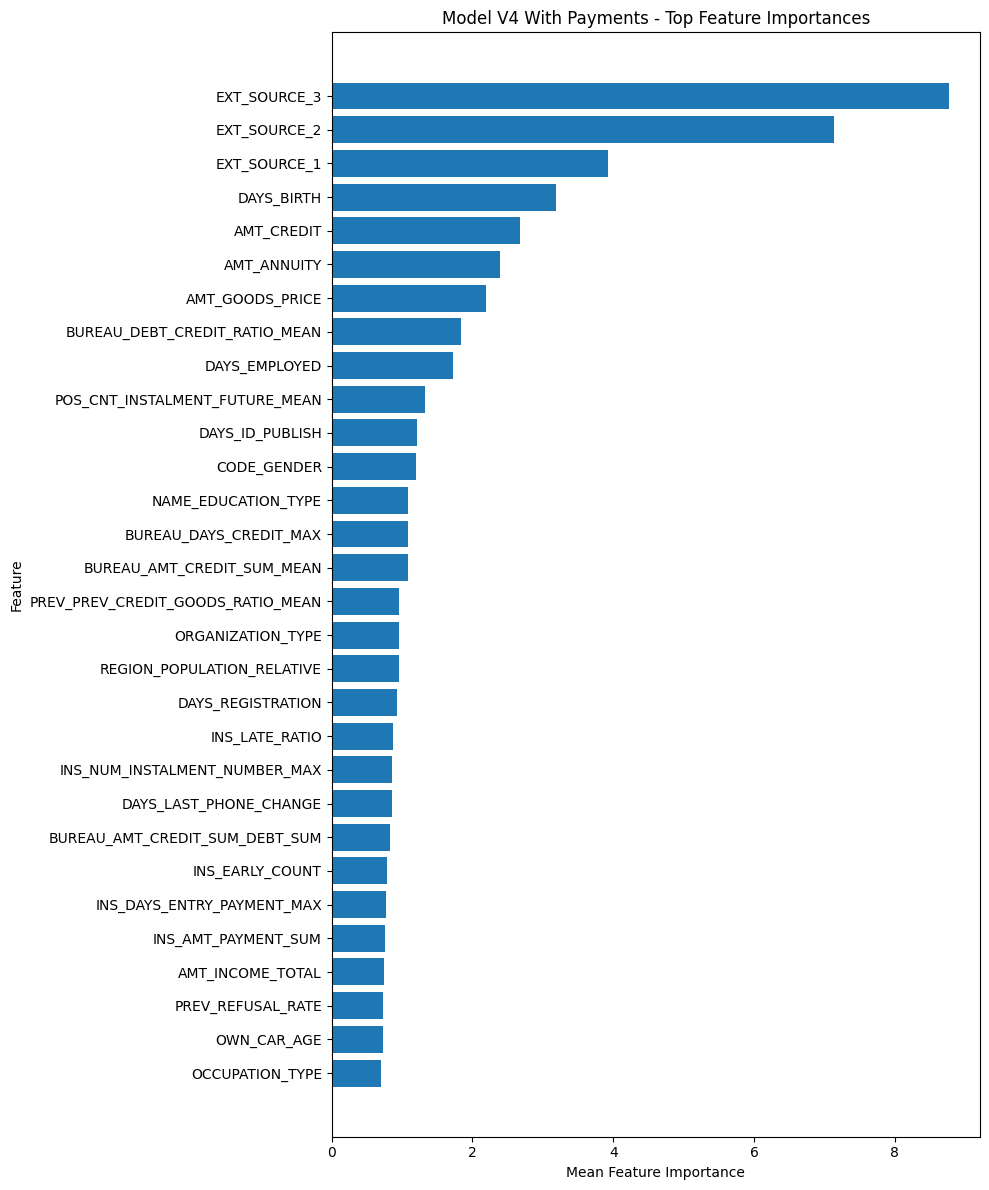

Saved figure: C:\Coding\Home-Credit-Default-Risk\outputs\figures\model_v4_with_payments_feature_importance.png


In [23]:
top_n = 30
plot_df = feature_importance_mean.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Mean Feature Importance")
plt.ylabel("Feature")
plt.title("Model V4 With Payments - Top Feature Importances")
plt.tight_layout()

figure_path = FIGURES_DIR / "model_v4_with_payments_feature_importance.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

In [24]:
feature_importance_path = REPORTS_DIR / "model_v4_with_payments_feature_importance.csv"
feature_importance_mean.to_csv(feature_importance_path, index=False)

print("Saved feature importance table:", feature_importance_path)

Saved feature importance table: C:\Coding\Home-Credit-Default-Risk\outputs\reports\model_v4_with_payments_feature_importance.csv


In [25]:
report_path = REPORTS_DIR / "model_v4_with_payments.md"

report_lines = [
    "# Model V4 Results - Main Table + Bureau + Previous + Payment History",
    "",
    "## Dataset",
    f"- Train shape: {train.shape}",
    f"- Test shape: {test.shape}",
    f"- Bureau feature table shape: {bureau_features.shape}",
    f"- Previous application feature table shape: {previous_features.shape}",
    f"- Payment history feature table shape: {payment_features.shape}",
    f"- Final merged train feature matrix: {train_model.shape}",
    f"- Final merged test feature matrix: {test_model.shape}",
    f"- Number of categorical columns: {len(cat_cols)}",
    f"- Number of numeric columns: {len(num_cols)}",
    "",
    "## Cross-validation",
    f"- Number of folds: {n_splits}",
    f"- Fold AUC scores: {[round(s, 6) for s in fold_scores]}",
    f"- Mean fold AUC: {np.mean(fold_scores):.6f}",
    f"- OOF AUC: {oof_auc:.6f}",
    "",
    "## Comparison",
    f"- Baseline OOF AUC: {baseline_oof_auc:.6f}",
    f"- Bureau + Previous OOF AUC: {bureau_previous_oof_auc:.6f}",
    f"- OOF lift vs baseline: {oof_auc - baseline_oof_auc:.6f}",
    f"- OOF lift vs bureau + previous: {oof_auc - bureau_previous_oof_auc:.6f}",
    "",
    "## Outputs",
    f"- Submission file: {submission_path}",
    f"- OOF predictions file: {oof_path}",
    f"- Feature importance figure: {figure_path}",
    f"- Feature importance table: {feature_importance_path}",
    "",
    "## Top 20 Features",
]

for row in feature_importance_mean.head(20).itertuples(index=False):
    report_lines.append(f"- {row.feature}: {row.importance:.6f}")

report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Saved report:", report_path)
print(report_path.read_text(encoding="utf-8")[:2000])

Saved report: C:\Coding\Home-Credit-Default-Risk\outputs\reports\model_v4_with_payments.md
# Model V4 Results - Main Table + Bureau + Previous + Payment History

## Dataset
- Train shape: (307511, 122)
- Test shape: (48744, 121)
- Bureau feature table shape: (356255, 37)
- Previous application feature table shape: (356255, 39)
- Payment history feature table shape: (356255, 115)
- Final merged train feature matrix: (307511, 310)
- Final merged test feature matrix: (48744, 309)
- Number of categorical columns: 16
- Number of numeric columns: 292

## Cross-validation
- Number of folds: 5
- Fold AUC scores: [0.781515, 0.790077, 0.783888, 0.78959, 0.781873]
- Mean fold AUC: 0.785389
- OOF AUC: 0.785274

## Comparison
- Baseline OOF AUC: 0.759895
- Bureau + Previous OOF AUC: 0.772974
- OOF lift vs baseline: 0.025379
- OOF lift vs bureau + previous: 0.012300

## Outputs
- Submission file: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\model_v4_with_payments.csv
- OOF predictions file

In [26]:
from pathlib import Path
import joblib

MODELS_DIR = project_root / "outputs" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

final_model_path = MODELS_DIR / "model_v4_with_payments_fold5.joblib"
joblib.dump(model, final_model_path)

print("Saved model:", final_model_path)

Saved model: c:\Coding\Home-Credit-Default-Risk\outputs\models\model_v4_with_payments_fold5.joblib
